# TP1 Transfert de chaleur en milieu poreux — Partie 2

## 2. Régime thermique transitoire


### 2.1 Forme générale


On considère la convention de notation suivante. $\boldsymbol{\nabla}$ est un opérateur différenciel et $\Delta$ le Laplacien. 
Les symboles en gras représentent des vecteurs. 

L'interface nappe-rivière est ici représentée par une portion de zone hyporhéique mono-dimensionnelle de hauteur h.

Le couple d'équations régissant le transfert de chaleur correspond d'une part à la résolution du régime permanent hydraulique (loi de Darcy):

$ \boldsymbol{q} = -K \boldsymbol{\nabla} H $

avec $\boldsymbol{q}$, le débit spécifique [$m.s^{-1}$],  
$H$, la charge [$m$]  
$K$, la perméabilité [$m.s^{-1}$],

Le système expérimental MOLONARI (MOnitoring LOcal des échanges NAppe-RIvière) permet de mesurer la différence de pression entre le haut et le bas de la colonne, qui est ainsi une donnée d'entrée du problème. A perméabilité considérée homogène le long de la colonne, le débit est ainsi évaluable pour le couplage avec l'équation de transfert de chaleur en régime permanent :

$\rho_m c_m \dfrac{\partial \theta}{\partial t} = - \rho_w c_w \boldsymbol{q} \cdot \boldsymbol{\nabla} \theta + \lambda_m \Delta \theta$

avec $\theta$, la température [$K$],  
$\rho_i$, la densité de i [$kg.m^{-3}$],  
$c_i$ la capacité calorifique spécifique de i [$J.kg^{-1}.K^{-1}$],  
$\lambda_i$ [$W.m^{-1}.K^{-1}$] la conductivité thermique de i,
où $i \in {s,w,m}$, avec s solide, w eau, m milieu poreux equivalent. 

$c_m\rho_m$ est estimé à partir de moyenne volumique pondérée par la porosité $n$ du milieu, $ \rho_m c_m = n \rho_w c_w + (1 - n) \rho_s c_s $

La conductivité thermique du milieu poreux équivalent est estimée par la relation $\lambda_m = \left( n \sqrt{\lambda_w} + (1-n) \sqrt{\lambda_s} \right)^2$.

### 2.2 Réduction de l'espace des paramètres

L'équation de transport de la chaleur peut être réécrite sous la forme :


$ \dfrac{\partial \theta}{\partial t} = \kappa_e \Delta \theta + 
\alpha_e \boldsymbol{\nabla} H \cdot \boldsymbol{\nabla} \theta $

avec $ \kappa_e = \dfrac{\lambda_m}{ \rho_m c_m }  $

$ \alpha_e = \dfrac{\rho_w c_w}{ \rho_m c_m} K $


$\kappa_e$ [$m^2 s^{-1}$] et $\alpha_e$ [$m s^{-1}$] sont des paramètres effectifs, dénommés respectivement conductivité effective (parfois dénommée effective diffusivité thermique) et paramètre advectif effectif.

### 2.3 Propagation d'un signal périodique dans un milieu semi infini

Il existe une solution analytique, fournie par Stallman (1965), à la propagation d'un signal de température sinusoïdal  à la surface d'un milieu poreux soumis à une différence de pressions ($\Delta H$) constante au cours du temps. Le signal sinusoïdal est apliqué en haut de la colonne, dans un repère dont l'origine est en haut de la colonne et orienté vers le bas. Il a une amplitude  $\theta_{amp}$ et une période P autour d'une valeur moyenne $\theta_{\mu}$. Cette solution s'écrit :

$ \theta(z,t)  = \theta_{\mu} + \theta_{amp} e^{-az} \cos\left( \dfrac{2 \pi}{P} t - b z \right) $  [eq.1]

avec 
$ a  = \dfrac{1}{2 \kappa_e} \left( \sqrt{\dfrac{\sqrt{v_t^4 + (8 \pi \kappa_e / P)^2 } + v_t^2}{2}} - v_t \right) $, 

$ b  = \dfrac{1}{2 \kappa_e}  \sqrt{\dfrac{\sqrt{v_t^4 + (8 \pi \kappa_e / P)^2 } - v_t^2}{2}} $, 

$ v_t  = - \alpha_e \dfrac{\partial H}{\partial z} $


Dans le cas conductif pur, la solution analytique s'écrit:

$ \theta(z,t)  = \theta_{\mu} + \theta_{amp} e^{-\sqrt{\dfrac{\pi}{\kappa_e P}}z} \cos\left( \dfrac{2 \pi}{P} t - \sqrt{\dfrac{\pi}{\kappa_e P}} z \right) $  [eq.1cond]



### 2.4 Etude de cas

Considérons une colonne de sol de 8 m de profondeur avec la conductivité thermique équivalente $\lambda_m = 1 W.m^{-1}.K^{-1}$, la porosité $ n = 0.15$, et la capacité calorifique équivalente $\rho_m c_m =  4e6 J.m^{-3}.K^{-1}$. La perméabilité est fixée à $8.10^{-4} m.s^{-1}$. 

#### 2.4.1 Réponse de la zone hyporhéique à une sollicitation thermique périodique

On considère un signal périodique en surface d'amplitude 1 K et une période de 720 heures (30 jours) autour d'un température moyenne de 12 °C.

##### 2.4.1.1 Evolution de la température dans le milieu

Tracer le profil des températures toutes les 30 heures pour les trois cas suivants :

+ 1. vitesse de darcy vers le haut de 1e-6 $m. s^{-1}$
+ 2. profil conductif pur
+ 3.  vitesse de darcy vers le bas de 1e-6 $m. s^{-1}$

Avant de démarrer, écrire une méthode permettant de forcer une simulation à partir de paramètres thermiques équivalents (conductivité thermique et capacité calorifique).

Tracer également des frises temporelles représentant la matrice des températures dans l'espace (z,t). 

Commentez ces résultats.

---
## Corrigé de la partie 2

### Méthode numérique

La colonne de hauteur $h$ (axe $z$ vers le bas, origine à la surface) est découpée en $n$ mailles de hauteur $\Delta z = h/n$ ; les températures $\theta_i$ sont calculées aux centres $z_i = (i-\tfrac12)\Delta z$ et les conditions limites sont imposées sur les **faces** $1/2$ et $n+1/2$.

En 1D, l'équation s'écrit sous forme conservative
$$\rho_m c_m\frac{\partial\theta}{\partial t} = -\frac{\partial F}{\partial z},\qquad F = \rho_w c_w\,q\,\theta - \lambda_m\frac{\partial\theta}{\partial z}$$
($q>0$ : écoulement vers le bas = infiltration). Intégrée sur la maille $i$ :
$$\rho_m c_m\frac{d\theta_i}{dt} = -\frac{F_{i+1/2}-F_{i-1/2}}{\Delta z}$$
- faces intérieures : $\theta_{i+1/2} = (\theta_i+\theta_{i+1})/2$ et $\partial_z\theta = (\theta_{i+1}-\theta_i)/\Delta z$ (différences finies centrées) ;
- face $1/2$ : $\theta = \theta_{top}(t)$ imposée, gradient $(\theta_1-\theta_{top})/(\Delta z/2)$ ;
- face $n+1/2$ : soit $\theta = \theta_{bot}$ imposée, soit **sortie libre** (flux conductif nul, l'eau sort à la température de la dernière maille).

In [ ]:
import numpy as np                                   # calcul sur tableaux (vecteurs, matrices)
import matplotlib.pyplot as plt                      # tracé des figures
from types import SimpleNamespace                    # petit "conteneur" : col.h, col.z... au lieu de col["h"]
from scipy.sparse import diags, identity             # matrices creuses : diags = matrice à partir de diagonales, identity = I
from scipy.sparse.linalg import splu                 # factorisation LU d'une matrice creuse (pour résoudre vite A x = b)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})   # résolution et taille de police par défaut des figures
HOUR, DAY, YEAR = 3600.0, 86400.0, 365.25 * 86400.0        # durées en secondes (le code travaille en unités SI)

# constantes de l'eau
RHO_W, C_W, LAMBDA_W, G = 1000.0, 4180.0, 0.6, 9.81   # masse volumique [kg/m3], capacité calorifique [J/kg/K], conductivité [W/m/K], gravité [m/s2]
RHOC_W = RHO_W * C_W                                  # capacité calorifique volumique de l'eau ρw cw [J/m3/K]


def make_column(h, ncell, K, lam_m, rhoc_m, scheme="centered"):
    """Colonne 1D : maillage (centres z, faces zf) + paramètres équivalents K, lambda_m, rho_m c_m."""
    dz = h / ncell                                    # hauteur d'une maille : Δz = h / n
    return SimpleNamespace(                           # on regroupe tout dans un seul objet "col"
        h=float(h),                                   # hauteur de la colonne [m]
        n=int(ncell),                                 # nombre de mailles
        dz=dz,                                        # pas d'espace [m]
        z=(np.arange(ncell) + 0.5) * dz,              # centres des mailles : z_i = (i - 1/2) Δz, i = 1..n
        zf=np.arange(ncell + 1) * dz,                 # faces : z_{i+1/2} = i Δz, i = 0..n (0 = surface, h = fond)
        K=float(K),                                   # perméabilité (conductivité hydraulique) [m/s]
        lam=float(lam_m),                             # conductivité thermique du milieu λm [W/m/K]
        rhoc=float(rhoc_m),                           # capacité calorifique du milieu ρm cm [J/m3/K]
        scheme=scheme)                                # schéma d'advection : "centered" (centré) ou "upwind" (amont)


def face_coefficients(n, dz, lam, adv, scheme="centered", bc_bot="dirichlet"):
    """Flux sur la face f :  F_f = FL[f] θ_{f-1} + FR[f] θ_f + ft[f] θ_top + fb[f] θ_bot
    (la face f sépare les mailles f-1 et f ; adv = rho_w c_w q aux n+1 faces)."""
    FL = np.zeros(n + 1)             # coefficient du flux de la face f devant θ de la maille du DESSUS (f-1)
    FR = np.zeros(n + 1)             # coefficient devant θ de la maille du DESSOUS (f)
    ft = np.zeros(n + 1)             # coefficient devant la température imposée en surface θ_top
    fb = np.zeros(n + 1)             # coefficient devant la température imposée au fond θ_bot
    a = adv[1:n]                     # ρw cw q sur les n-1 faces intérieures (faces 1 à n-1)
    if scheme == "centered":
        wL = np.full(n - 1, 0.5)     # centré : θ_face = 0.5 θ_{f-1} + 0.5 θ_f
    else:
        wL = (a >= 0).astype(float)  # amont : on prend la maille d'où vient l'eau (dessus si q > 0, dessous si q < 0)
    # faces intérieures : F = ρw cw q θ_face - λ (θ_f - θ_{f-1}) / Δz
    FL[1:n] = a * wL + lam / dz       # part advective (poids wL) + part conductive (+λ/Δz devant θ_{f-1})
    FR[1:n] = a * (1 - wL) - lam / dz # part advective (poids 1-wL) + part conductive (-λ/Δz devant θ_f)
    # face 1/2 (surface) : θ = θ_top imposée, le centre de la maille 1 est à Δz/2 de la face
    ft[0] = adv[0] + 2 * lam / dz     # F = ρw cw q θ_top - λ (θ_1 - θ_top)/(Δz/2) -> coefficient de θ_top
    FR[0] = -2 * lam / dz             # -> coefficient de θ_1
    # face n+1/2 (fond)
    if bc_bot == "dirichlet":         # température imposée au fond
        fb[n] = adv[n] - 2 * lam / dz # F = ρw cw q θ_bot - λ (θ_bot - θ_n)/(Δz/2) -> coefficient de θ_bot
        FL[n] = 2 * lam / dz          # -> coefficient de θ_n
    return FL, FR, ft, fb             # renvoie les 4 tableaux de coefficients


def assemble(n, dz, lam, adv, scheme="centered", bc_bot="dirichlet"):
    """Bilan sur chaque maille :  C dθ/dt = -(F_{i+1/2} - F_{i-1/2})/dz = A θ + Bt θ_top + Bb θ_bot."""
    FL, FR, ft, fb = face_coefficients(n, dz, lam, adv, scheme, bc_bot)   # flux sur toutes les faces
    lower = FL[1:n] / dz                  # sous-diagonale : A[i, i-1] = +FL[i]/Δz (flux entrant par la face du haut)
    main = -(FL[1:] - FR[:-1]) / dz       # diagonale : A[i, i] = -(FL[i+1] - FR[i])/Δz (θ_i apparaît dans ses 2 faces)
    upper = -FR[1:n] / dz                 # sur-diagonale : A[i, i+1] = -FR[i+1]/Δz (flux sortant par la face du bas)
    A = diags([lower, main, upper], [-1, 0, 1], format="csc")   # matrice tridiagonale creuse n x n
    Bt = np.zeros(n)                      # vecteur multipliant θ_top : seule la maille 1 touche la surface
    Bb = np.zeros(n)                      # vecteur multipliant θ_bot : seule la maille n touche le fond
    Bt[0] = ft[0] / dz                    # contribution de la face 1/2 au bilan de la maille 1 (signe + : flux entrant)
    Bb[-1] = -fb[n] / dz                  # contribution de la face n+1/2 au bilan de la maille n (signe - : flux sortant)
    return A, Bt, Bb


def plot_profiles(ax, z, T, labels=None, cmap="viridis", **kw):
    """Trace plusieurs profils T[k, :] (axe z vers le bas)."""
    T = np.atleast_2d(T)                                     # un seul profil -> tableau à 1 ligne
    colors = plt.get_cmap(cmap)(np.linspace(0, 1, T.shape[0], endpoint=cmap != "twilight"))  # une couleur par profil
    for k, prof in enumerate(T):                             # boucle sur les profils
        lab = None if labels is None else labels[k]          # légende éventuelle
        ax.plot(prof, z, color=colors[k], label=lab, **kw)   # température en abscisse, profondeur en ordonnée
    if not ax.yaxis_inverted():                              # profondeur croissante vers le bas
        ax.invert_yaxis()
    ax.set_xlabel("Température [°C]")
    ax.set_ylabel("Profondeur z [m]")
    ax.grid(alpha=0.3)                                       # grille légère
    return ax

### Réponse 2.4 — Mise en place du cas d'étude

La cellule suivante code les outils fournis par l'énoncé en 2.2–2.3 : paramètres effectifs $\kappa_e = \lambda_m/\rho_m c_m$, $\alpha_e = \rho_w c_w K/\rho_m c_m$, vitesse thermique $v_t = -\alpha_e\,\partial H/\partial z = \rho_w c_w q/\rho_m c_m$ (axe $z$ vers le bas, $q>0$ = infiltration) et solution de Stallman [eq.1], qui sert de référence pour valider le modèle numérique.

La fonction `from_equivalent(h, ncell, K, lam_m, rhoc_m)` **force la simulation à partir des paramètres thermiques équivalents** ($\lambda_m$, $\rho_m c_m$) sans passer par $n$, $\lambda_s$, $\rho_s c_s$ (la porosité $n=0.15$ n'est alors plus utile au calcul).

Le débit de Darcy imposé correspond à une différence de charge $\Delta H = qh/K = 10^{-6}\times 8/8\cdot10^{-4} = 1$ cm entre le haut et le bas de la colonne.

Choix numériques : $\Delta z = 1$ cm (800 mailles), $\Delta t = 30$ min, Crank–Nicolson. Conditions limites :
- en surface, $\theta_{top}(t) = \theta_\mu + \theta_{amp}\cos(2\pi t/P)$ ;
- au fond : $\theta = 12$ °C (Dirichlet) en conductif et en exfiltration (l'eau de nappe entre par le bas à 12 °C) ; **sortie libre** en infiltration, car le signal n'est pas amorti à 8 m (on le vérifie plus bas) et une Dirichlet créerait une couche limite artificielle.

La solution de Stallman correspond au **régime périodique établi** : on simule 5 périodes à partir d'un état initial uniforme à 12 °C et on n'analyse que la dernière.

In [ ]:
# --- paramètres effectifs (énoncé 2.2)
def kappa_e(col):
    """Diffusivité thermique effective [m²/s]."""
    return col.lam / col.rhoc                         # κe = λm / (ρm cm)

def alpha_e(col):
    """Paramètre advectif effectif [m/s]."""
    return RHOC_W / col.rhoc * col.K                  # αe = ρw cw K / (ρm cm)

def v_t(col, q):
    """Vitesse thermique v_t = -alpha_e dH/dz = rho_w c_w q / rho_m c_m."""
    return RHOC_W * np.asarray(q) / col.rhoc          # vitesse à laquelle la chaleur est transportée (≠ q)

def dH_from_q(col, q):
    """Différence de charge H_haut - H_bas donnant le débit q."""
    return q * col.h / col.K                          # Darcy : q = K ΔH / h  =>  ΔH = q h / K

# --- solution analytique de Stallman (énoncé 2.3, eq.1)
def stallman_ab(P, kappa, vt):
    """a (amortissement) et b (déphasage) de l'énoncé.
    On utilise sqrt((S+v²)/2) - v = ((S-v²)/2) / (sqrt((S+v²)/2) + v) avec S - v² = w²/(S+v²),
    formes équivalentes qui évitent la soustraction de deux nombres presque égaux quand v_t > 0."""
    P, vt = np.broadcast_arrays(np.asarray(P, float), np.asarray(vt, float))  # accepte scalaires ou tableaux (P et vt de même forme)
    w = 8 * np.pi * kappa / P                         # w = 8πκe/P (terme de l'énoncé)
    v2 = vt ** 2                                      # v_t²
    S = np.sqrt(v2 ** 2 + w ** 2)                     # S = sqrt(v_t⁴ + (8πκe/P)²)
    A = np.sqrt((S + v2) / 2)                         # A = sqrt((S + v_t²)/2)
    SmV = w ** 2 / (S + v2)                           # S - v_t² calculé sans soustraction : (S-v²)(S+v²) = S² - v⁴ = w²
    with np.errstate(divide="ignore", invalid="ignore"):   # np.where calcule les deux branches : on masque les avertissements
        a = np.where(vt >= 0,                         # si v_t >= 0 : A - v_t = ((S-v²)/2)/(A + v_t)  (forme stable)
                     (SmV / 2) / (A + vt),
                     A - vt) / (2 * kappa)            # si v_t < 0 : A - v_t = A + |v_t| (pas de problème) ; puis /(2κe)
    b = np.sqrt(SmV / 2) / (2 * kappa)                # b = sqrt((S - v_t²)/2) / (2κe)
    return a, b


def stallman(z, t, P, amp, mean, kappa, vt):
    """θ(z,t) = θμ + θamp exp(-a z) cos(2π t/P - b z)   [eq.1]"""
    a, b = stallman_ab(P, kappa, vt)                  # coefficients d'amortissement et de déphasage
    z = np.asarray(z)                                 # profondeurs (tableau)
    t = np.asarray(t)                                 # temps (tableau)
    return mean + amp * np.exp(-a * z) * np.cos(2 * np.pi * t / P - b * z)   # formule [eq.1]


# --- modèle transitoire
def from_equivalent(h, ncell, K, lam_m, rhoc_m):
    """Force une simulation à partir des paramètres thermiques ÉQUIVALENTS (λm, ρm cm)."""
    return make_column(h, ncell, K, lam_m, rhoc_m)    # on donne directement λm et ρm cm (pas n, λs, ρs cs)


def series(x, nt):
    """Scalaire ou tableau -> série de longueur nt."""
    x = np.asarray(x, dtype=float)                    # conversion en tableau numpy
    if x.ndim == 0:                                   # si c'est un nombre (valeur constante dans le temps)...
        return np.full(nt, float(x))                  # ...on le répète nt fois
    return x                                          # sinon c'est déjà une série temporelle


def solve_transient(col, t, theta_top, theta_bot=np.nan, q=0.0, theta0=None,
                    bc_bot="dirichlet", gamma=0.5, save_every=1):
    """γ-schéma (γ = 1/2 : Crank-Nicolson), q constant, pas de temps constant.
    Retourne (temps sauvés, T[nt_sauvés, n])."""
    t = np.asarray(t, float)                          # instants de calcul [s]
    nt = t.size                                       # nombre d'instants
    dt = t[1] - t[0]                                  # pas de temps (supposé constant)
    tt = series(theta_top, nt)                        # température de surface à chaque instant
    tb = np.nan_to_num(series(theta_bot, nt))         # température du fond (NaN -> 0, sans effet si bc_bot = 'free')
    adv = np.full(col.n + 1, RHOC_W * q)              # ρw cw q sur chaque face (q uniforme)
    A, Bt, Bb = assemble(col.n, col.dz, col.lam, adv, col.scheme, bc_bot)   # système ρm cm dθ/dt = Aθ + Bt θtop + Bb θbot
    I = identity(col.n, format="csc")                 # matrice identité creuse
    # γ-schéma : (C/Δt I - γA) θ^{k+1} = (C/Δt I + (1-γ)A) θ^k + γ b^{k+1} + (1-γ) b^k
    lu = splu((col.rhoc / dt * I - gamma * A).tocsc())  # matrice de gauche, factorisée UNE fois (constante)
    R = (col.rhoc / dt * I + (1 - gamma) * A).tocsr()    # matrice de droite
    if theta0 is None:                                # état initial non fourni :
        th = np.full(col.n, tt.mean())                # colonne uniforme à la température moyenne de surface
    else:
        th = np.array(theta0, float)                  # sinon on part de l'état donné
    out = [th.copy()]                                 # liste des profils sauvegardés (on garde l'état initial)
    tout = [t[0]]                                     # liste des temps correspondants
    for k in range(nt - 1):                           # boucle en temps : on passe de t_k à t_{k+1}
        b_top = gamma * tt[k + 1] + (1 - gamma) * tt[k]   # moyenne pondérée de θ_top entre t_k et t_{k+1}
        b_bot = gamma * tb[k + 1] + (1 - gamma) * tb[k]   # idem pour θ_bot
        rhs = R @ th + Bt * b_top + Bb * b_bot            # second membre
        th = lu.solve(rhs)                                # nouvelle température θ^{k+1}
        if (k + 1) % save_every == 0 or k == nt - 2:      # on ne stocke qu'un pas sur save_every (+ le dernier)
            out.append(th.copy())
            tout.append(t[k + 1])
    return np.array(tout), np.array(out)              # temps sauvés (nt_s,) et températures (nt_s, n)

In [ ]:
H_COL, NCELL = 8.0, 800                               # colonne de 8 m découpée en 800 mailles -> Δz = 1 cm
LAM_M, RHOC_M, K_CAS, N_POR = 1.0, 4e6, 8e-4, 0.15    # λm [W/m/K], ρm cm [J/m3/K], K [m/s], porosité (non utilisée : paramètres équivalents)
col = from_equivalent(H_COL, NCELL, K_CAS, LAM_M, RHOC_M)   # création de la colonne à partir des paramètres équivalents
kap = kappa_e(col)                                    # diffusivité effective κe = 1/4e6 = 2.5e-7 m²/s
print(f"kappa_e = {kap:.3e} m²/s   alpha_e = {alpha_e(col):.3e} m/s")   # affichage des deux paramètres effectifs

# les 3 cas demandés : q > 0 vers le bas (axe z orienté vers le bas)
cases = {
    "Ascendant (exfiltration)":  dict(q=-1e-6, bc="dirichlet", c="tab:blue"),  # eau de nappe à 12 °C qui entre par le fond
    "Conductif pur":             dict(q=0.0,   bc="dirichlet", c="k"),         # pas d'écoulement
    "Descendant (infiltration)": dict(q=+1e-6, bc="free",      c="tab:red"),   # l'eau sort par le fond : sortie libre
}
for name, cs in cases.items():                        # pour chaque cas...
    cs["vt"] = v_t(col, cs["q"])                      # ...vitesse thermique correspondante
    dH_cm = dH_from_q(col, cs["q"]) * 100             # différence de charge équivalente [cm]
    Pe = abs(RHOC_W * cs["q"]) * col.dz / col.lam     # Péclet de maille (< 2 : schéma centré sans oscillation)
    print(f"{name:27s} q = {cs['q']:+.0e} m/s  ΔH = {dH_cm:+.1f} cm  v_t = {cs['vt']:+.3e} m/s  Pe_maille = {Pe:.3f}")

kappa_e = 2.500e-07 m²/s   alpha_e = 8.360e-04 m/s
Ascendant (exfiltration)    q = -1e-06 m/s  ΔH = -1.0 cm  v_t = -1.045e-06 m/s  Pe_maille = 0.042
Conductif pur               q = +0e+00 m/s  ΔH = +0.0 cm  v_t = +0.000e+00 m/s  Pe_maille = 0.000
Descendant (infiltration)   q = +1e-06 m/s  ΔH = +1.0 cm  v_t = +1.045e-06 m/s  Pe_maille = 0.042


#### 2.4.1.1 Évolution de la température dans le milieu

In [ ]:
P, AMP, TMU = 720 * HOUR, 1.0, 12.0                   # période 720 h [s], amplitude 1 K, moyenne 12 °C
DT = 0.5 * HOUR                                       # pas de temps : 30 min
t = np.arange(0, 5 * P + DT / 2, DT)                  # 5 périodes (4 pour atteindre le régime périodique + 1 analysée)
theta_top = TMU + AMP * np.cos(2 * np.pi * t / P)     # signal sinusoïdal imposé en surface

for name, cs in cases.items():                        # simulation de chacun des 3 cas
    ts, T = solve_transient(col, t, theta_top, TMU, q=cs["q"], bc_bot=cs["bc"],
                            save_every=2)             # save_every=2 : on stocke un profil par heure
    last = ts >= 4 * P - 1                            # masque : instants de la dernière période
    cs["t"] = ts[last] - 4 * P                        # temps de la dernière période ramenés à [0, P]
    cs["T"] = T[last]                                 # températures correspondantes (720+1 profils x 800 mailles)
    cs["ttop"] = TMU + AMP * np.cos(2 * np.pi * cs["t"] / P)   # signal de surface sur cette période (utile pour les flux)
    Tana = stallman(col.z[None, :], cs["t"][:, None], P, AMP, TMU, kap, cs["vt"])   # solution exacte sur la grille (t, z)
    cs["a"], cs["b"] = stallman_ab(P, kap, cs["vt"])  # a et b gardés pour les questions suivantes
    err = np.abs(cs["T"] - Tana).max()                # écart maximal numérique / analytique
    amp8 = AMP * np.exp(-cs["a"] * H_COL)             # amplitude théorique restante à 8 m
    print(f"{name:27s} écart max numérique/Stallman sur la dernière période : {err:.1e} K ; amplitude à 8 m : {amp8:.1e} K")

Ascendant (exfiltration)    écart max numérique/Stallman sur la dernière période : 3.3e-04 K ; amplitude à 8 m : 1.7e-17 K


Conductif pur               écart max numérique/Stallman sur la dernière période : 3.6e-04 K ; amplitude à 8 m : 2.2e-08 K


Descendant (infiltration)   écart max numérique/Stallman sur la dernière période : 5.4e-03 K ; amplitude à 8 m : 5.6e-03 K


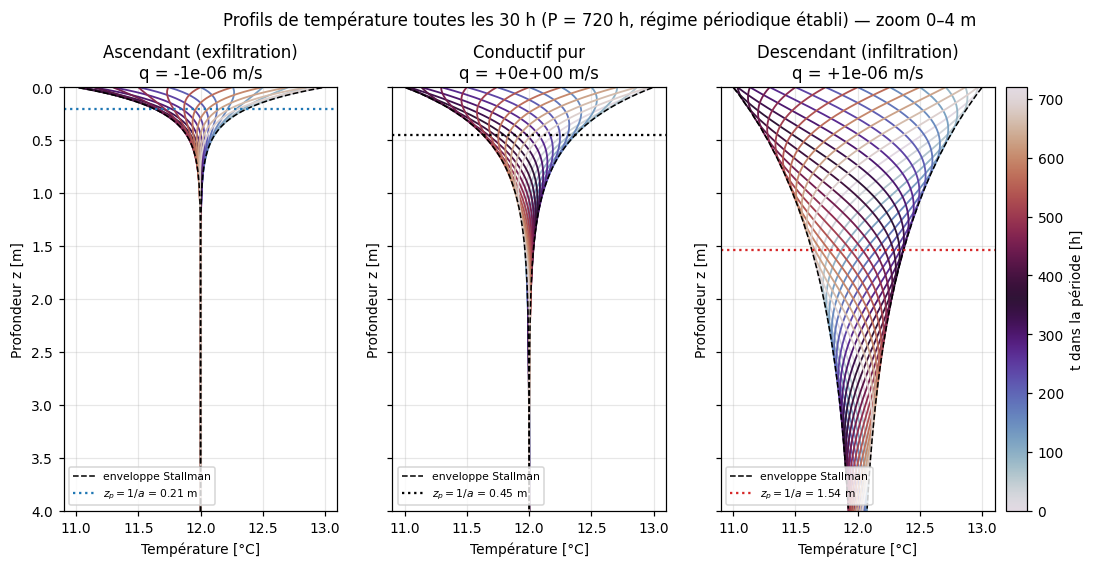

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)   # 3 graphiques côte à côte, même axe z
every30 = np.arange(0, 720, 30)                       # indices 0, 30, 60... (profils horaires -> un toutes les 30 h)
for ax, (name, cs) in zip(axes, cases.items()):       # un graphique par cas
    plot_profiles(ax, col.z, cs["T"][every30], cmap="twilight", lw=1.2)   # 24 profils, couleur = instant dans la période
    env = AMP * np.exp(-cs["a"] * col.z)              # enveloppe théorique θamp e^{-az}
    ax.plot(TMU + env, col.z, "k--", lw=1, label="enveloppe Stallman")    # borne haute
    ax.plot(TMU - env, col.z, "k--", lw=1)            # borne basse
    ax.axhline(1 / cs["a"], color=cs["c"], ls=":", label=f"$z_p = 1/a$ = {1/cs['a']:.2f} m")   # profondeur de pénétration
    ax.set_title(f"{name}\nq = {cs['q']:+.0e} m/s")   # titre
    ax.set_xlim(10.9, 13.1)                           # plage de température affichée
    ax.legend(fontsize=7, loc="lower left")
axes[0].set_ylim(4, 0)                                # zoom sur les 4 premiers mètres (axe partagé -> vaut pour les 3)
sm = plt.cm.ScalarMappable(cmap="twilight", norm=plt.Normalize(0, 720))   # échelle de couleur temps 0-720 h
fig.colorbar(sm, ax=axes, label="t dans la période [h]", pad=0.01)        # barre de couleur commune
fig.suptitle("Profils de température toutes les 30 h (P = 720 h, régime périodique établi) — zoom 0–4 m", y=1.02)
plt.show()

In [ ]:
def plot_frise(ax, t, z, F, cmap="RdBu_r", vmin=None, vmax=None, label="", tunit=DAY, zmax=None):
    """Frise temporelle F[t, z] dans le plan (t, z)."""
    m = ax.pcolormesh(t / tunit, z, np.asarray(F).T,  # carte colorée : x = temps (en tunit), y = profondeur ; .T car F est [t, z]
                      cmap=cmap, vmin=vmin, vmax=vmax,  # palette et bornes de couleur
                      shading="auto", rasterized=True)  # rasterized : figure plus légère
    if zmax is None:
        zmax = z.max()                                # par défaut toute la colonne
    ax.set_ylim(zmax, 0)                              # profondeur vers le bas
    ax.set_ylabel("z [m]")
    ax.figure.colorbar(m, ax=ax, label=label, pad=0.01)   # barre de couleur
    return m

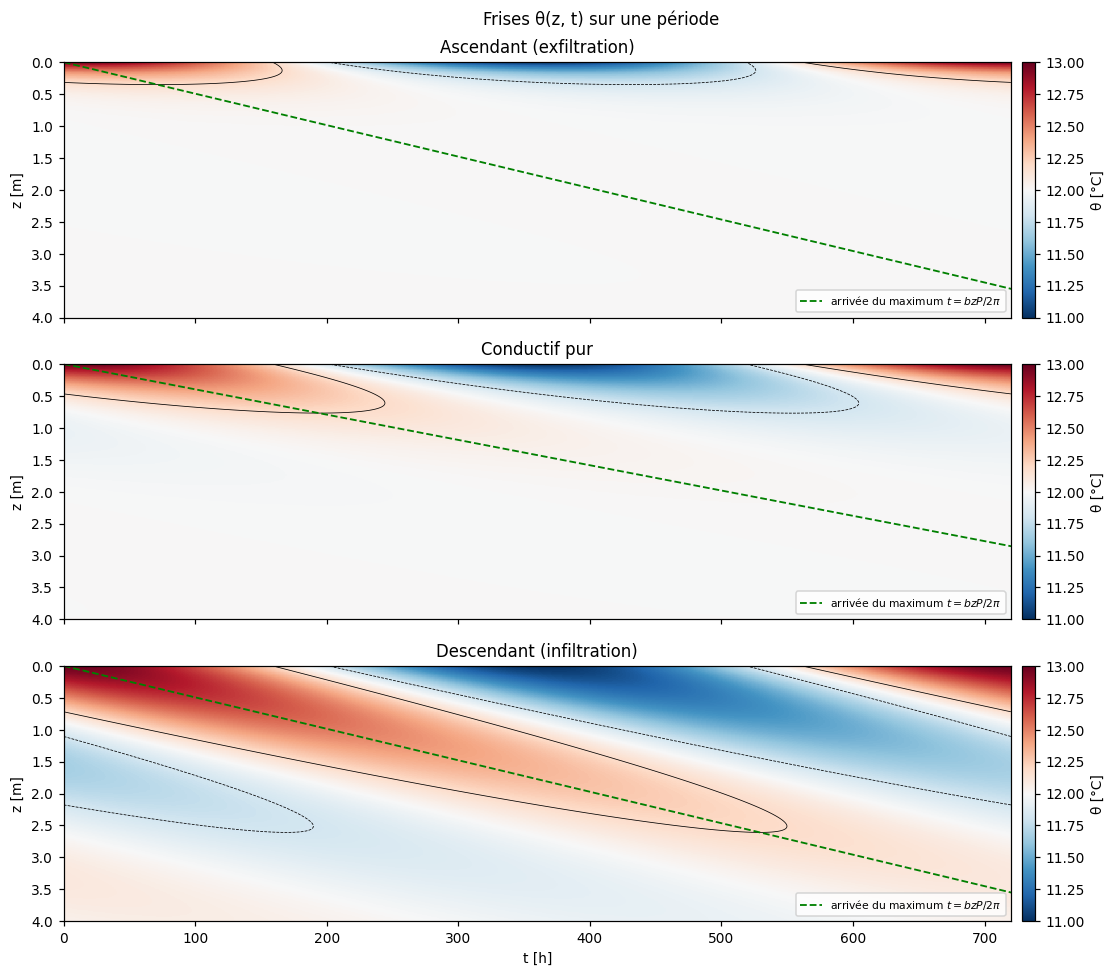

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)   # 3 frises l'une sous l'autre
for ax, (name, cs) in zip(axes, cases.items()):
    plot_frise(ax, cs["t"], col.z, cs["T"], vmin=11, vmax=13, label="θ [°C]", tunit=HOUR, zmax=4)   # θ(z, t) sur une période
    lev = 0.5 * np.exp(-1)                            # isothermes θμ ± 0.18 K pour visualiser la propagation
    ax.contour(cs["t"] / HOUR, col.z, (cs["T"] - TMU).T, levels=[-lev, lev], colors="k", linewidths=0.5)
    # ligne d'arrivée du maximum : t = b z P / (2 pi)  (cf. 2.4.1.4)
    zz = np.linspace(0, 4, 200)                       # profondeurs de 0 à 4 m
    ta = (cs["b"] * zz * P / (2 * np.pi)) / HOUR      # temps d'arrivée théorique du maximum [h]
    ax.plot(ta, zz, "g--", lw=1.2, label="arrivée du maximum $t = bzP/2\\pi$")
    ax.set_title(name)
    ax.legend(fontsize=7, loc="lower right")
axes[-1].set_xlabel("t [h]")                          # légende de l'axe x sur la dernière frise seulement
axes[-1].set_xlim(0, 720)                             # une période
fig.suptitle("Frises θ(z, t) sur une période")
plt.tight_layout()
plt.show()

**Commentaires 2.4.1.1**

- **Validation.** Sur la dernière période simulée, l'écart entre le modèle numérique et la solution de Stallman est de quelques millièmes de degré au plus (1 % de l'amplitude) : le code est validé en transitoire. En infiltration, l'amplitude vaut encore ≈ 5·10⁻³ K à 8 m, ce qui justifie la condition de sortie libre au fond.
- **Conduction pure** : le signal est amorti et déphasé de la même façon ($a = b = \sqrt{\pi/\kappa_e P} \approx 2.2$ m⁻¹) ; il est réduit à $e^{-1}$ à 0.45 m et devient négligeable (< 0.01 K) au‑delà de ~2 m. Les profils forment le classique « fuseau » de Kelvin autour de 12 °C, avec des inversions de gradient en profondeur (l'onde se propage, on voit les maxima « descendre » sur la frise).
- **Exfiltration (q < 0)** : l'eau de nappe qui remonte à 12 °C « repousse » le signal vers la surface. L'amortissement est beaucoup plus fort ($z_p \approx 0.21$ m) et le fuseau est écrasé contre la surface : la zone hyporhéique est thermiquement tamponnée par la nappe.
- **Infiltration (q > 0)** : l'eau de la rivière transporte le signal vers le bas. L'amortissement est plus faible ($z_p \approx 1.5$ m, 3.4 fois le cas conductif) ; les isothermes de la frise sont nettement inclinées : c'est la signature d'un transport advectif.
- Les écoulements ascendant et descendant de même intensité ont des pentes d'isothermes (lignes vertes) identiques : on montre en 2.4.1.4 que **le déphasage $b$ ne dépend que de $v_t^2$**, alors que l'amortissement $a$ dépend du signe de $v_t$. C'est l'amplitude, et non le retard, qui indique le sens de l'écoulement.

##### 2.4.1.2 Quantifier et représentez les flux d'énergie relatifs à ces états thermiques

Tracer également des frises temporelles représentant les flux de chaleur advectifs et conductifs relatifs aux trois cas précédents. Commentez ces résultats.

#### Réponse 2.4.1.2

Les flux sont calculés aux faces (positifs vers le bas) :
$$F_{adv} = \rho_w c_w\, q\,(\theta - \theta_{ref}),\qquad F_{cond} = -\lambda_m\frac{\partial\theta}{\partial z}$$
Le flux advectif dépend du choix de la température de référence (seules ses **différences** ont un sens physique). On prend $\theta_{ref} = \theta_\mu = 12$ °C : $F_{adv}$ représente alors la part du transport d'énergie liée à la perturbation thermique.

In [ ]:
def fluxes(col, T, theta_top, theta_bot=np.nan, q=0.0, bc_bot="dirichlet", theta_ref=0.0):
    """Flux aux faces [W/m²], positifs vers le bas : F_adv = ρw cw q (θ - θref), F_cond = -λm dθ/dz."""
    T = np.atleast_2d(T)                              # tableau [temps, maille]
    nt, n, dz = T.shape[0], col.n, col.dz             # nombre d'instants, de mailles, pas d'espace
    tt = series(theta_top, nt)                        # θ_top à chaque instant
    tb = series(theta_bot, nt)                        # θ_bot à chaque instant
    face = np.empty((nt, n + 1))                      # température sur les n+1 faces
    grad = np.empty((nt, n + 1))                      # gradient dθ/dz sur les n+1 faces
    face[:, 1:n] = 0.5 * (T[:, :-1] + T[:, 1:])       # faces intérieures : moyenne des deux mailles voisines
    grad[:, 1:n] = np.diff(T, axis=1) / dz            # faces intérieures : (θ_{i+1} - θ_i) / Δz
    face[:, 0] = tt                                   # surface : température imposée
    grad[:, 0] = (T[:, 0] - tt) / (dz / 2)            # surface : demi-maille entre la face et le 1er centre
    if bc_bot == "dirichlet":                         # fond à température imposée
        face[:, n] = tb
        grad[:, n] = (tb - T[:, -1]) / (dz / 2)
    else:                                             # sortie libre : θ de la dernière maille, gradient nul
        face[:, n] = T[:, -1]
        grad[:, n] = 0.0
    F_adv = RHOC_W * q * (face - theta_ref)           # flux advectif (dépend de la température de référence)
    F_cond = -col.lam * grad                          # flux conductif (loi de Fourier)
    return col.zf, F_adv, F_cond                      # profondeurs des faces et les deux flux [t, face]

Ascendant (exfiltration)    amplitude en surface : |F_adv| =  4.18 W/m² (théorie ρw cw |q| θamp = 4.18) ; |F_cond| =  5.14 W/m² (théorie λ θamp √(a²+b²) = 5.14)
Conductif pur               amplitude en surface : |F_adv| =  0.00 W/m² (théorie ρw cw |q| θamp = 0.00) ; |F_cond| =  3.11 W/m² (théorie λ θamp √(a²+b²) = 3.11)
Descendant (infiltration)   amplitude en surface : |F_adv| =  4.18 W/m² (théorie ρw cw |q| θamp = 4.18) ; |F_cond| =  1.89 W/m² (théorie λ θamp √(a²+b²) = 1.89)


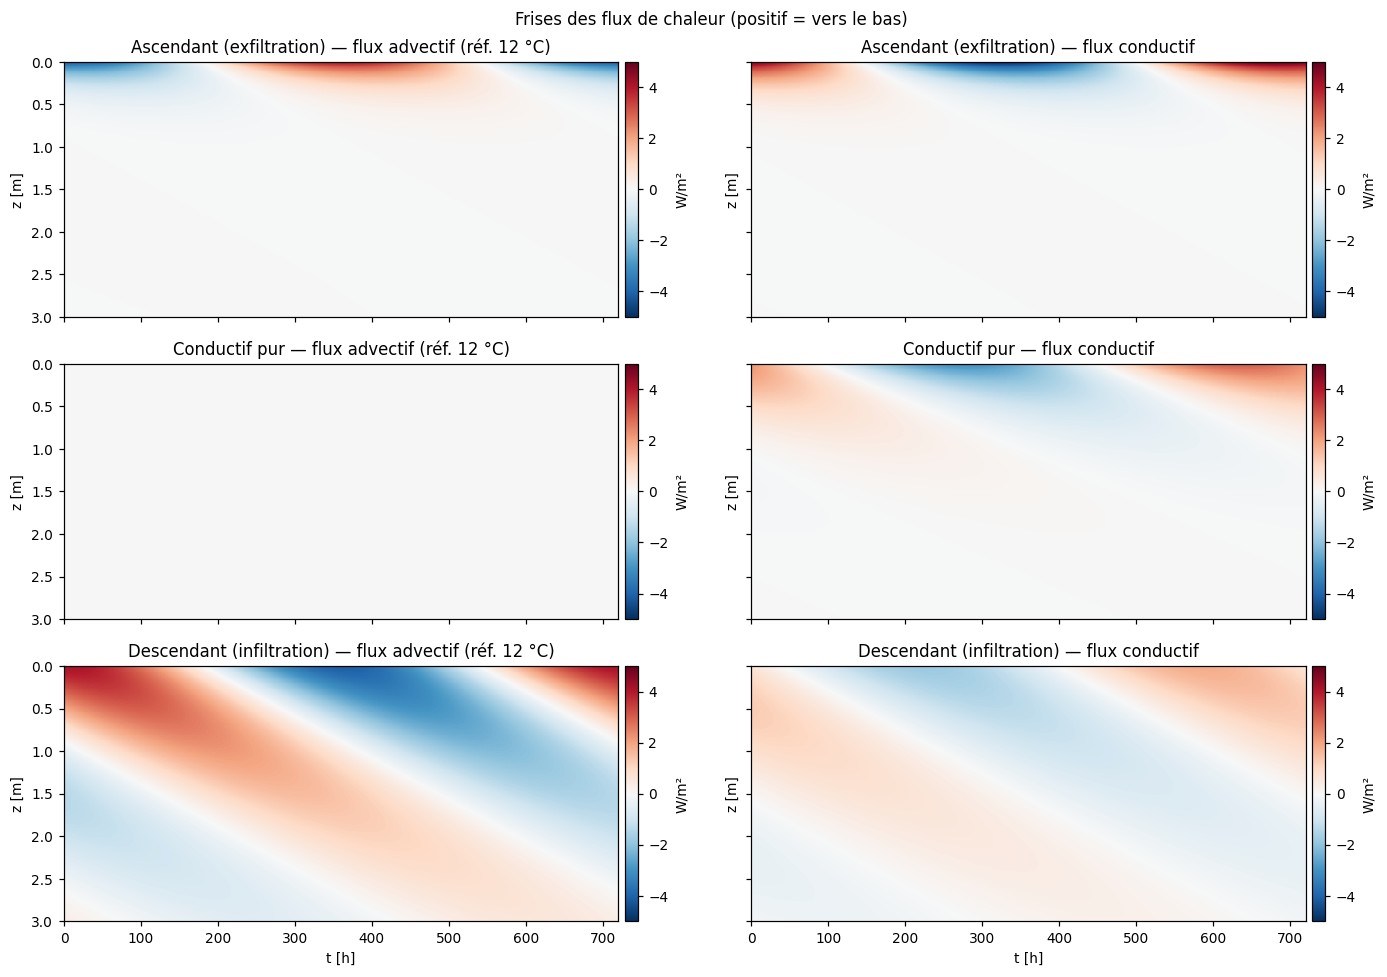

In [ ]:
for name, cs in cases.items():
    zf, cs["Fadv"], cs["Fcond"] = fluxes(col, cs["T"], cs["ttop"], TMU, q=cs["q"],
                                         bc_bot=cs["bc"], theta_ref=TMU)   # flux relatifs à 12 °C
    grad_amp = AMP * np.hypot(cs["a"], cs["b"])       # amplitude théorique du gradient en surface : θamp sqrt(a² + b²)
    Fadv0 = np.abs(cs["Fadv"][:, 0]).max()            # amplitude simulée du flux advectif en surface
    Fcond0 = np.abs(cs["Fcond"][:, 0]).max()          # amplitude simulée du flux conductif en surface
    print(f"{name:27s} amplitude en surface : |F_adv| = {Fadv0:5.2f} W/m² (théorie ρw cw |q| θamp = {RHOC_W*abs(cs['q'])*AMP:4.2f}) ; "
          f"|F_cond| = {Fcond0:5.2f} W/m² (théorie λ θamp √(a²+b²) = {LAM_M*grad_amp:4.2f})")

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True, sharey=True)   # lignes = cas, colonnes = advectif / conductif
for i, (name, cs) in enumerate(cases.items()):
    plot_frise(axes[i, 0], cs["t"], zf, cs["Fadv"], vmin=-5, vmax=5, label="W/m²", tunit=HOUR, zmax=3)    # frise flux advectif
    plot_frise(axes[i, 1], cs["t"], zf, cs["Fcond"], vmin=-5, vmax=5, label="W/m²", tunit=HOUR, zmax=3)   # frise flux conductif
    axes[i, 0].set_title(f"{name} — flux advectif (réf. 12 °C)")
    axes[i, 1].set_title(f"{name} — flux conductif")
for ax in axes[-1]:
    ax.set_xlabel("t [h]")                            # axe du temps sur la dernière ligne
fig.suptitle("Frises des flux de chaleur (positif = vers le bas)")
plt.tight_layout()
plt.show()

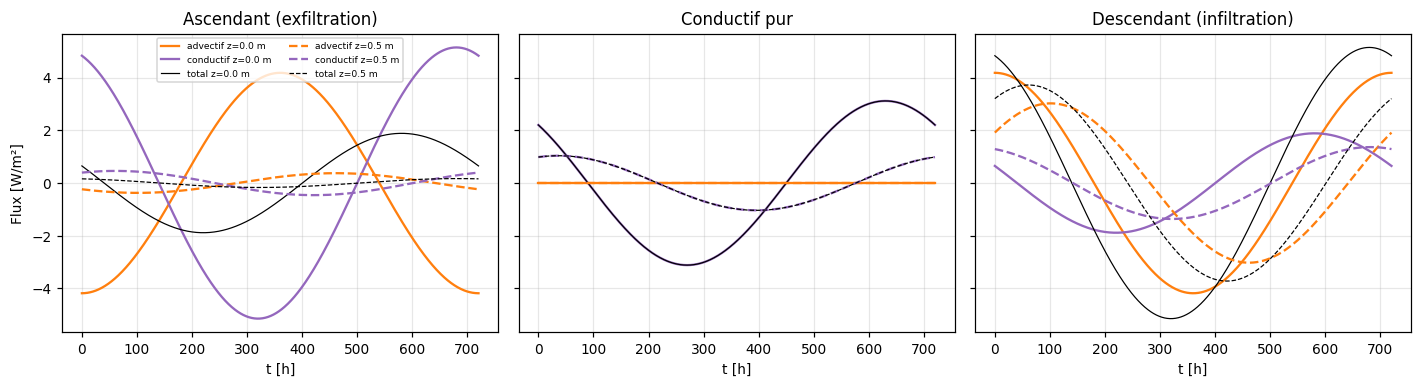

Ascendant (exfiltration)    énergie entrant dans le sol pendant la demi-période chaude :  1.55 MJ/m²
Conductif pur               énergie entrant dans le sol pendant la demi-période chaude :  2.57 MJ/m²
Descendant (infiltration)   énergie entrant dans le sol pendant la demi-période chaude :  4.24 MJ/m²


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)   # un graphique par cas
j05 = np.searchsorted(zf, 0.5)                        # indice de la face située à 0.5 m
for ax, (name, cs) in zip(axes, cases.items()):
    for j, ls in [(0, "-"), (j05, "--")]:             # trait plein : surface ; tirets : 0.5 m
        t_h = cs["t"] / HOUR                          # temps en heures
        ax.plot(t_h, cs["Fadv"][:, j], color="tab:orange", ls=ls, label=f"advectif z={zf[j]:.1f} m")
        ax.plot(t_h, cs["Fcond"][:, j], color="tab:purple", ls=ls, label=f"conductif z={zf[j]:.1f} m")
        ax.plot(t_h, cs["Fadv"][:, j] + cs["Fcond"][:, j], color="k", ls=ls, lw=.8, label=f"total z={zf[j]:.1f} m")
    ax.set_title(name)
    ax.set_xlabel("t [h]")
    ax.grid(alpha=.3)
axes[0].set_ylabel("Flux [W/m²]")
axes[0].legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

# énergie qui entre dans le sol au cours d'un cycle (à partir de la surface)
for name, cs in cases.items():
    Ftot0 = cs["Fadv"][:, 0] + cs["Fcond"][:, 0]      # flux total en surface au cours du temps
    E_in = np.trapezoid(np.clip(Ftot0, 0, None), cs["t"]) / 1e6   # intégrale de la partie positive (entrante) -> MJ/m²
    print(f"{name:27s} énergie entrant dans le sol pendant la demi-période chaude : {E_in:5.2f} MJ/m²")

**Commentaires 2.4.1.2**

- **Conduction pure** : $F_{adv}=0$ ; le flux conductif en surface est en avance de $\pi/4$ (1/8 de période, 90 h) sur la température : le sol se charge en énergie avant le maximum de température puis la restitue. L'amplitude théorique $\lambda\,\theta_{amp}\sqrt{a^2+b^2} = \sqrt2\,\lambda\theta_{amp}\sqrt{\pi/\kappa_e P} \approx 3.1$ W/m² est retrouvée.
- **Exfiltration** : le flux advectif (ascendant, $q<0$) apporte en permanence de l'eau à 12 °C vers la surface ; il est en opposition avec la perturbation en surface ($F_{adv}<0$ quand la surface est chaude). Pour maintenir le signal en surface, le gradient doit être fort : le flux conductif est le plus élevé des trois cas (~5 W/m²) mais il est confiné dans les ~50 premiers centimètres. Les deux flux se compensent largement et le flux total qui pénètre est **faible** : c'est le régime de « couche limite thermique ».
- **Infiltration** : le flux advectif domine (4.2 W/m² contre ~1.9 W/m² pour la conduction en surface) et reste significatif sur plus de 2 m : c'est lui qui transporte l'énergie en profondeur. Le flux conductif, plus faible, joue surtout le rôle de dispersion du front. C'est dans ce cas que le sol échange le plus d'énergie avec la rivière sur un cycle.
- En moyenne sur une période, les deux flux perturbés sont nuls (régime périodique) : ce qui entre pendant la phase chaude ressort pendant la phase froide.

##### 2.4.1.3 Profondeur de pénétration

Par convention on considère que la profondeur de pénétration d'une onde est définie par la profondeur à partir de laquelle l'amplitude est amortie de $e^{-1}$, soit environ d'un tiers.

__Calculer la profondeur de pénétration__

#### Réponse 2.4.1.3

L'amplitude à la profondeur $z$ vaut $\theta_{amp}e^{-az}$ : elle est réduite d'un facteur $e^{-1}$ pour
$$\boxed{z_p = \frac{1}{a} = \frac{2\kappa_e}{\sqrt{\dfrac{\sqrt{v_t^4 + (8\pi\kappa_e/P)^2}+v_t^2}{2}} - v_t}}
\qquad\text{conductif : } z_p = \sqrt{\frac{\kappa_e P}{\pi}}$$

On compare avec la profondeur mesurée sur les simulations (amplitude ajustée par moindres carrés à chaque profondeur).

In [ ]:
def fit_sinus(t, series_, P):
    """Amplitude et phase (moindres carrés) de series_[t, z] ~ m + amp cos(2πt/P - phase)."""
    w = 2 * np.pi / P                                 # pulsation ω
    X = np.column_stack([np.ones_like(t), np.cos(w * t), np.sin(w * t)])   # modèle linéaire : m + c cos(ωt) + s sin(ωt)
    coef, *_ = np.linalg.lstsq(X, series_, rcond=None)   # moindres carrés, pour toutes les profondeurs à la fois
    amp = np.hypot(coef[1], coef[2])                  # amplitude = sqrt(c² + s²)
    phase = np.unwrap(np.arctan2(coef[2], coef[1]))   # phase = atan(s/c), "déroulée" pour être continue en z
    return amp, phase

In [ ]:
for name, cs in cases.items():
    amp_num, _ = fit_sinus(cs["t"], cs["T"], P)       # amplitude simulée à chaque profondeur
    z_num = np.interp(np.exp(-1), amp_num[::-1] / AMP, col.z[::-1])   # profondeur où amp/θamp = e^{-1} (interpolation ; tableaux
                                                                      # inversés car np.interp veut des x croissants)
    print(f"{name:27s} z_p analytique = {1/cs['a']:.3f} m   z_p simulé = {z_num:.3f} m")
print(f"Conductif (formule simplifiée √(κP/π)) = {np.sqrt(kap*P/np.pi):.3f} m")   # vérification du cas conductif

Ascendant (exfiltration)    z_p analytique = 0.207 m   z_p simulé = 0.207 m
Conductif pur               z_p analytique = 0.454 m   z_p simulé = 0.454 m
Descendant (infiltration)   z_p analytique = 1.541 m   z_p simulé = 1.541 m
Conductif (formule simplifiée √(κP/π)) = 0.454 m


__Tracer les profondeurs de pénétration__ pour des signaux périodiques dont la période varie entre 1hr et 1 an. Pour des vitesses descendantes, ascendantes variant en valeur absolue entre 10$^{-5}$ et 10$^{-8}$ m.s$^{-1}$. On utilisera des échelles log.

Commentez ces résultats.

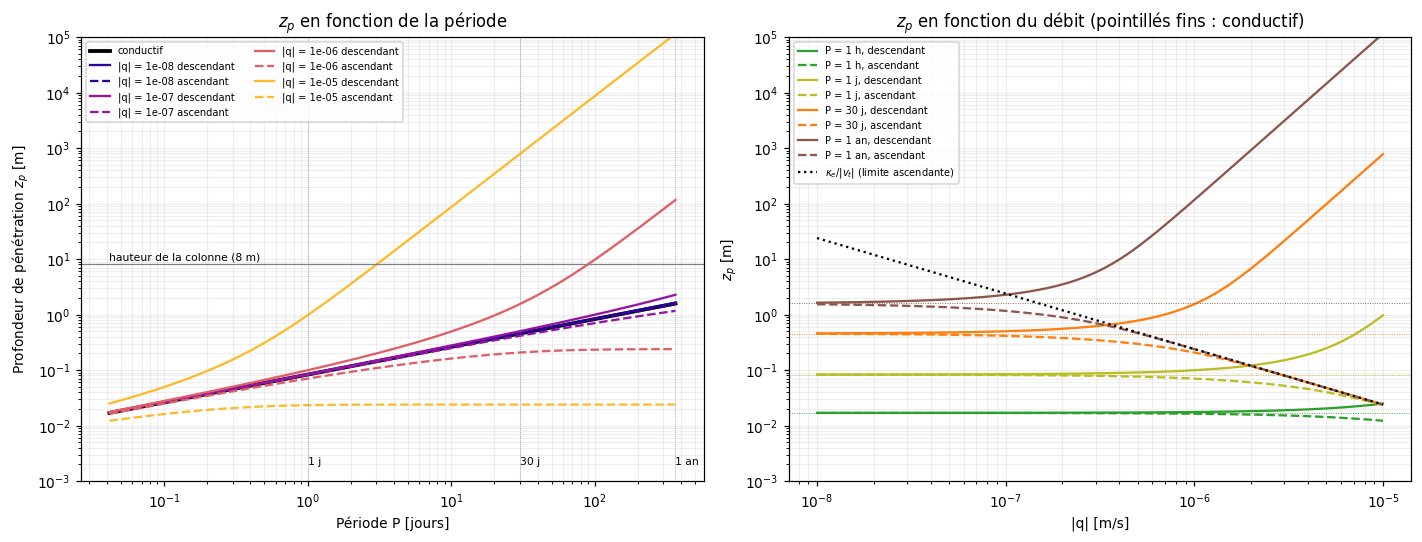

|q| = 1e-08 m/s : période de transition P_c = 8πκ/v_t² =   6.66e+05 jours
|q| = 1e-07 m/s : période de transition P_c = 8πκ/v_t² =   6.66e+03 jours
|q| = 1e-06 m/s : période de transition P_c = 8πκ/v_t² =       66.6 jours
|q| = 1e-05 m/s : période de transition P_c = 8πκ/v_t² =      0.666 jours


In [ ]:
Ps = np.logspace(np.log10(HOUR), np.log10(YEAR), 300)   # 300 périodes réparties en échelle log entre 1 h et 1 an
def plab(Pv):                                           # étiquette lisible d'une période
    if Pv < DAY:
        return "1 h"
    if Pv > 300 * DAY:
        return "1 an"
    return f"{Pv/DAY:g} j"
qs = [1e-8, 1e-7, 1e-6, 1e-5]                           # valeurs absolues de débit demandées [m/s]
cols_q = plt.cm.plasma(np.linspace(0.05, 0.85, len(qs)))   # une couleur par débit

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# --- gauche : z_p en fonction de la période
ax = axes[0]
ax.loglog(Ps / DAY, np.sqrt(kap * Ps / np.pi), "k", lw=2.5, label="conductif")   # z_p = sqrt(κP/π)
for q, c in zip(qs, cols_q):
    for s, ls in [(+1, "-"), (-1, "--")]:               # s = +1 : descendant ; s = -1 : ascendant
        a, _ = stallman_ab(Ps, kap, v_t(col, s * q))    # a pour toutes les périodes d'un coup
        sens = "descendant" if s > 0 else "ascendant"
        ax.loglog(Ps / DAY, 1 / a, color=c, ls=ls, label=f"|q| = {q:.0e} {sens}")   # z_p = 1/a
ax.axhline(H_COL, color="grey", lw=.8)                  # repère : hauteur de la colonne
ax.text(Ps[0] / DAY, H_COL * 1.2, "hauteur de la colonne (8 m)", fontsize=7)
for Pmark, lab in [(DAY, "1 j"), (30 * DAY, "30 j"), (YEAR, "1 an")]:   # repères de période
    ax.axvline(Pmark / DAY, color="grey", lw=.5, ls=":")
    ax.text(Pmark / DAY, 2e-3, lab, fontsize=7)
ax.set_ylim(1e-3, 1e5)
ax.set_xlabel("Période P [jours]")
ax.set_ylabel("Profondeur de pénétration $z_p$ [m]")
ax.set_title("$z_p$ en fonction de la période")
ax.legend(fontsize=6.5, ncol=2)
ax.grid(which="both", alpha=.2)

# --- droite : z_p en fonction du débit pour 4 périodes
ax = axes[1]
qq = np.logspace(-8, -5, 200)                           # débits de 1e-8 à 1e-5 m/s
for Pv, c in zip([HOUR, DAY, 30 * DAY, YEAR], ["tab:green", "tab:olive", "tab:orange", "tab:brown"]):
    a_d, _ = stallman_ab(Pv, kap, v_t(col, qq))         # descendant (v_t > 0)
    a_u, _ = stallman_ab(Pv, kap, v_t(col, -qq))        # ascendant (v_t < 0)
    ax.loglog(qq, 1 / a_d, color=c, label=f"P = {plab(Pv)}, descendant")
    ax.loglog(qq, 1 / a_u, color=c, ls="--", label=f"P = {plab(Pv)}, ascendant")
    ax.axhline(np.sqrt(kap * Pv / np.pi), color=c, lw=.6, ls=":")   # valeur conductive de référence
ax.loglog(qq, kap / v_t(col, qq), "k:", lw=1.5, label="$\\kappa_e/|v_t|$ (limite ascendante)")   # asymptote ascendante
ax.set_ylim(1e-3, 1e5)
ax.set_xlabel("|q| [m/s]")
ax.set_ylabel("$z_p$ [m]")
ax.set_title("$z_p$ en fonction du débit (pointillés fins : conductif)")
ax.legend(fontsize=6.5)
ax.grid(which="both", alpha=.2)
plt.tight_layout()
plt.show()

for q in qs:                                            # période de transition conduction / advection
    Pc = 8 * np.pi * kap / v_t(col, q) ** 2             # P_c = 8πκe / v_t²
    print(f"|q| = {q:.0e} m/s : période de transition P_c = 8πκ/v_t² = {Pc/DAY:10.3g} jours")

**Commentaires 2.4.1.3**

- Le paramètre qui compare advection et conduction pour un signal périodique est $v_t^2 / (8\pi\kappa_e/P)$, soit une **période de transition** $P_c = 8\pi\kappa_e/v_t^2$ :
  - pour $P \ll P_c$ (en pratique $P \lesssim P_c/100$ ; l'écart est déjà de ~40 % à $P_c/20$, cf. le signal annuel avec $|q|=10^{-7}$ m/s), toutes les courbes rejoignent la loi conductive $z_p=\sqrt{\kappa_e P/\pi}$ (pente 1/2 en log‑log) : les signaux rapides « ne voient pas » l'écoulement. Avec $|q| = 10^{-8}$ m/s ($P_c$ ≈ 1 500 ans) l'écoulement est invisible quelle que soit la période ;
  - pour $P \gg P_c$, le sens de l'écoulement devient déterminant.
- **Écoulement descendant** : $z_p \simeq \dfrac{v_t^3P^2}{4\pi^2\kappa_e}$ croît comme $P^2$ : l'onde est transportée par l'eau. Pour $q = 10^{-5}$ m/s même le signal journalier pénètre de plusieurs mètres, et le signal annuel à $10^{-6}$ m/s atteint ≈ 100 m (bien au‑delà de la colonne de 8 m).
- **Écoulement ascendant** : $z_p$ sature à $\kappa_e/|v_t|$ (0.24 m pour $10^{-6}$ m/s, 2.4 cm pour $10^{-5}$ m/s), indépendamment de la période. C'est l'épaisseur de la couche limite thermique imposée par l'eau de nappe : aucun signal, même annuel, ne peut descendre plus bas.
- Conséquence pratique pour MOLONARI : pour être sensible au débit, on doit choisir des capteurs dont la profondeur est de l'ordre de $z_p$ du signal utilisé ; le signal journalier (quelques cm à dizaines de cm) est le plus informatif pour des débits $\gtrsim 10^{-6}$ m/s, alors que pour des débits faibles seul un signal long (saisonnier) contient de l'information advective.

##### 2.4.1.4 Temps d'arrivée d'une perturbation à une profondeur donnée

En analysant la composante ondulatoire de a solution analytique [eq.1], définir le __temps d'arrivée__ à une profondeur $z$ d'une perturbation de période $P$. En déterminer la vitesse la vitesse de propagation de l'onde.

#### Réponse 2.4.1.4

La partie ondulatoire de [eq.1] est $\cos\left(\dfrac{2\pi}{P}t - bz\right)$. Un état donné de l'onde (par exemple le maximum, phase nulle) atteint la profondeur $z$ lorsque $\dfrac{2\pi}{P}t - bz = 0$, soit le **temps d'arrivée**
$$\boxed{t_a(z) = \frac{b\,P}{2\pi}\,z}\qquad(\text{défini modulo } P)$$
Le temps d'arrivée est proportionnel à la profondeur ; la **vitesse de propagation** (vitesse de phase) est donc
$$\boxed{v_\varphi = \frac{z}{t_a} = \frac{2\pi}{bP} = \frac{\omega}{b}}\qquad\text{conductif : } v_\varphi = \sqrt{\frac{4\pi\kappa_e}{P}}$$

Propriétés remarquables :
- $b$ ne dépend que de $v_t^2$ : **le temps d'arrivée est le même pour un écoulement ascendant ou descendant de même intensité** ;
- limite advective ($v_t^2 \gg 8\pi\kappa_e/P$) : $b \to \omega/|v_t|$, donc $v_\varphi \to |v_t|$ ; la perturbation se propage à la vitesse thermique ;
- limite conductive : $v_\varphi \propto P^{-1/2}$, les signaux rapides se propagent plus vite (mais s'amortissent sur une distance plus courte).

Vérification sur les simulations : la phase mesurée à chaque profondeur doit valoir $bz$.

Ascendant (exfiltration)    b = 1.770 1/m  v_phi = 1.369e-06 m/s = 11.8 cm/j  t_a(0.5 m) = 101 h
Conductif pur               b = 2.202 1/m  v_phi = 1.101e-06 m/s = 9.5 cm/j  t_a(0.5 m) = 126 h
Descendant (infiltration)   b = 1.770 1/m  v_phi = 1.369e-06 m/s = 11.8 cm/j  t_a(0.5 m) = 101 h


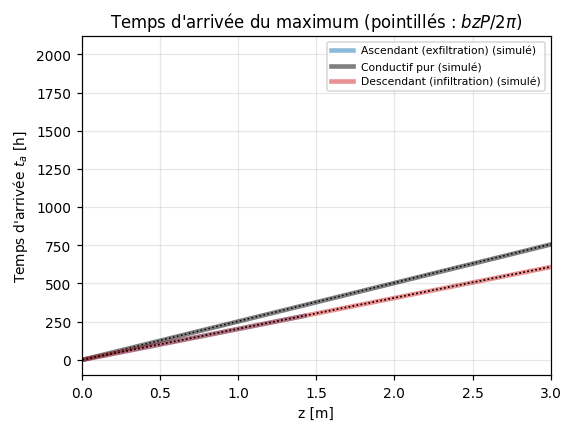

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for name, cs in cases.items():
    amp_num, ph = fit_sinus(cs["t"], cs["T"], P)      # amplitude et phase simulées à chaque profondeur
    ok = amp_num > 1e-3                               # on ignore les profondeurs où le signal est trop faible
    t_arr = (ph[ok] - ph[0]) * P / (2 * np.pi) / HOUR # déphasage converti en temps d'arrivée [h] : t = φ P / 2π
    ax.plot(col.z[ok], t_arr, color=cs["c"], lw=3, alpha=.5, label=f"{name} (simulé)")
    ax.plot(col.z, cs["b"] * col.z * P / (2 * np.pi) / HOUR, "k:", lw=1)   # théorie : t_a = b z P / 2π
    v_phi = 2 * np.pi / (cs["b"] * P)                 # vitesse de propagation v_φ = 2π / (bP)
    t05 = cs["b"] * 0.5 * P / (2 * np.pi) / HOUR      # temps d'arrivée à 0.5 m [h]
    print(f"{name:27s} b = {cs['b']:.3f} 1/m  v_phi = {v_phi:.3e} m/s = {v_phi*DAY*100:.1f} cm/j  t_a(0.5 m) = {t05:.0f} h")
ax.set_xlabel("z [m]")
ax.set_ylabel("Temps d'arrivée $t_a$ [h]")
ax.set_xlim(0, 3)
ax.set_title("Temps d'arrivée du maximum (pointillés : $bzP/2\\pi$)")
ax.legend(fontsize=7)
ax.grid(alpha=.3)
plt.show()

__Tracer les vitesses de propagation__ pour une gamme de vitesses variant entre 1e-5 m/s et 1e-8 m/s, et pour le cas conductif. Commentez vos résultats

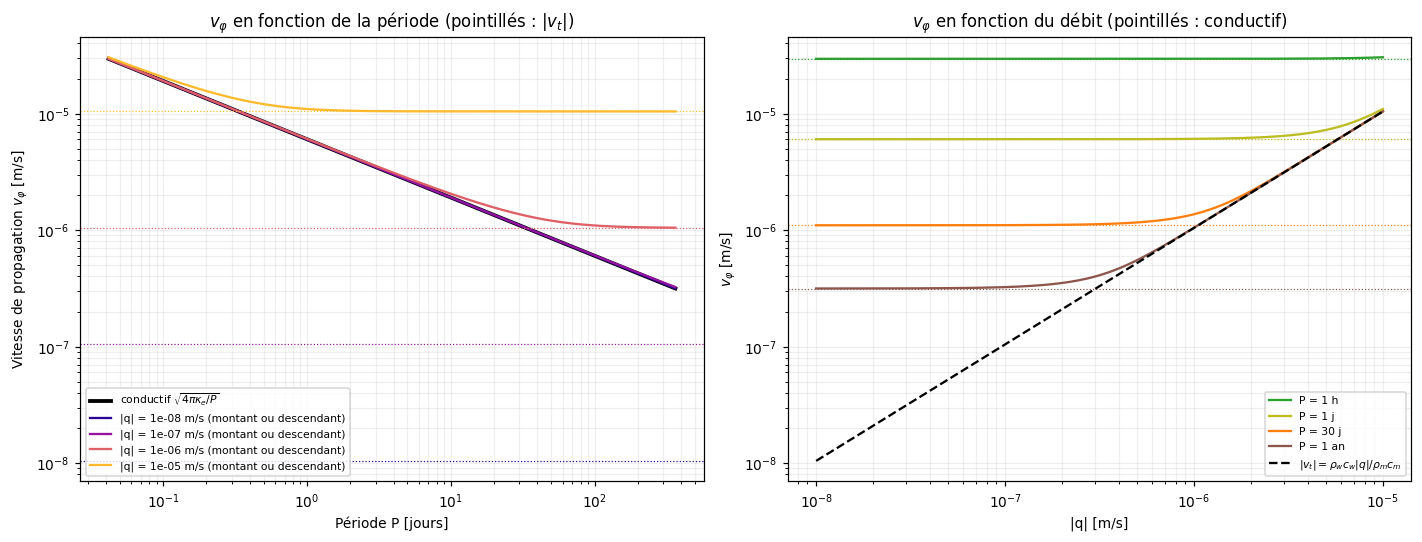

t_a(1 m), P =    1.0 j : |q|=0e+00:    1.92 j  |q|=1e-08:    1.92 j  |q|=1e-07:    1.92 j  |q|=1e-06:    1.91 j  |q|=1e-05:    1.06 j
t_a(1 m), P =   30.0 j : |q|=0e+00:   10.51 j  |q|=1e-08:   10.51 j  |q|=1e-07:   10.49 j  |q|=1e-06:    8.45 j  |q|=1e-05:    1.11 j
t_a(1 m), P =  365.2 j : |q|=0e+00:   36.68 j  |q|=1e-08:   36.67 j  |q|=1e-07:   35.69 j  |q|=1e-06:   11.03 j  |q|=1e-05:    1.11 j


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# --- gauche : v_φ en fonction de la période
ax = axes[0]
ax.loglog(Ps / DAY, np.sqrt(4 * np.pi * kap / Ps), "k", lw=2.5, label="conductif $\\sqrt{4\\pi\\kappa_e/P}$")
for q, c in zip(qs, cols_q):
    _, b = stallman_ab(Ps, kap, v_t(col, q))          # b ne dépend que de v_t² : même courbe montant/descendant
    ax.loglog(Ps / DAY, 2 * np.pi / (b * Ps), color=c, label=f"|q| = {q:.0e} m/s (montant ou descendant)")
    ax.axhline(v_t(col, q), color=c, ls=":", lw=.8)   # limite des longues périodes : v_φ -> |v_t|
ax.set_xlabel("Période P [jours]")
ax.set_ylabel("Vitesse de propagation $v_\\varphi$ [m/s]")
ax.set_title("$v_\\varphi$ en fonction de la période (pointillés : $|v_t|$)")
ax.legend(fontsize=7)
ax.grid(which="both", alpha=.2)

# --- droite : v_φ en fonction du débit pour 4 périodes
ax = axes[1]
for Pv, c in zip([HOUR, DAY, 30 * DAY, YEAR], ["tab:green", "tab:olive", "tab:orange", "tab:brown"]):
    _, b = stallman_ab(Pv, kap, v_t(col, qq))
    ax.loglog(qq, 2 * np.pi / (b * Pv), color=c, label=f"P = {plab(Pv)}")
    ax.axhline(np.sqrt(4 * np.pi * kap / Pv), color=c, ls=":", lw=.8)   # valeur conductive
ax.loglog(qq, v_t(col, qq), "k--", label="$|v_t| = \\rho_w c_w |q| / \\rho_m c_m$")   # vitesse thermique
ax.set_xlabel("|q| [m/s]")
ax.set_ylabel("$v_\\varphi$ [m/s]")
ax.set_title("$v_\\varphi$ en fonction du débit (pointillés : conductif)")
ax.legend(fontsize=7)
ax.grid(which="both", alpha=.2)
plt.tight_layout()
plt.show()

# exemple : temps d'arrivée à 1 m pour 3 périodes et plusieurs débits
for Pv in [DAY, 30 * DAY, YEAR]:
    parts = []
    for q in [0.0] + qs:
        b = stallman_ab(Pv, kap, v_t(col, q))[1]      # déphasage b
        ta = b * 1.0 * Pv / (2 * np.pi) / DAY         # t_a(z = 1 m) en jours
        parts.append(f"|q|={q:.0e}: {ta:7.2f} j")
    print(f"t_a(1 m), P = {Pv/DAY:6.1f} j : " + "  ".join(parts))

**Commentaires 2.4.1.4**

- La vérification numérique confirme $t_a = bzP/2\pi$ : le maximum de température met ≈ 127 h pour atteindre 0.5 m en conduction pure, ≈ 102 h avec $|q| = 10^{-6}$ m/s, que l'écoulement soit montant ou descendant.
- $v_\varphi$ est toujours **supérieure ou égale** à la vitesse conductive et à $|v_t|$ : l'écoulement accélère la propagation de la phase, quel que soit son sens. Pour $P \ll P_c$ on retrouve la loi conductive (décroissance en $P^{-1/2}$) ; pour $P \gg P_c$ la vitesse se stabilise à $|v_t|$ (plateaux horizontaux).
- En conduction pure, le signal journalier se propage à ~2 cm/h (≈ 2 jours pour atteindre 1 m, où il est de toute façon totalement amorti) et le signal annuel à ~2.7 cm/jour (≈ 37 jours pour 1 m). Avec $|q| = 10^{-5}$ m/s, le temps d'arrivée à 1 m tombe à ≈ 1.1 jour quelle que soit la période : c'est $1/|v_t|$, la propagation est purement advective.
- **Interprétation** : le déphasage seul ne renseigne que sur $|v_t|$, pas sur le sens d'écoulement ; il faut combiner **amplitude** (sensible au signe) et **phase** (sensible à $\kappa_e$ et $|v_t|$). C'est le principe des méthodes d'inversion fondées sur le rapport d'amplitude et le déphasage entre deux capteurs (Hatch et al. 2006, Keery et al. 2007 — références à vérifier).
- En exfiltration, le temps d'arrivée garde un sens mathématique mais la perturbation est tellement amortie ($z_p \ll$ longueur d'onde) qu'il n'est pas mesurable au‑delà de quelques $z_p$.

#### 2.4.2 Sollicitations multi-périodiques
 
On considère maintenant deux signaux périodiques emboîtés, l'un annuel (d'amplitude 6 °C), l'autre journalier d'amplitude 1°C.

Représenter tout d'abord les deux influences séparemment puis voir comment elles se combinent dans le milieu pour les deux cas infliltrant et exfiltrant à une vitesse de Darcy de +/-1e-6 $m. s^{-1}$. Représentez les profils verticaux et les frises.

Commentez les résultats obtenus.

#### Réponse 2.4.2

Signal en surface : $\theta_{top}(t) = 12 + 6\cos\left(\dfrac{2\pi t}{P_a}\right) + 1\cdot\cos\left(\dfrac{2\pi t}{P_j}\right)$, avec $P_a = 365.25$ j et $P_j = 1$ j ($t=0$ : maximum annuel, c'est‑à‑dire le cœur de l'été).

L'équation est **linéaire** en $\theta$ (à $q$ fixé) : la réponse au signal combiné est la **somme** des réponses à chaque composante. On le vérifie numériquement.

**Étape 1 — influences séparées.** Signal annuel seul (Δt = 3 h, 3 ans de simulation, dernière année analysée) et signal journalier seul (Δt = 15 min, 10 jours, dernier jour analysé).

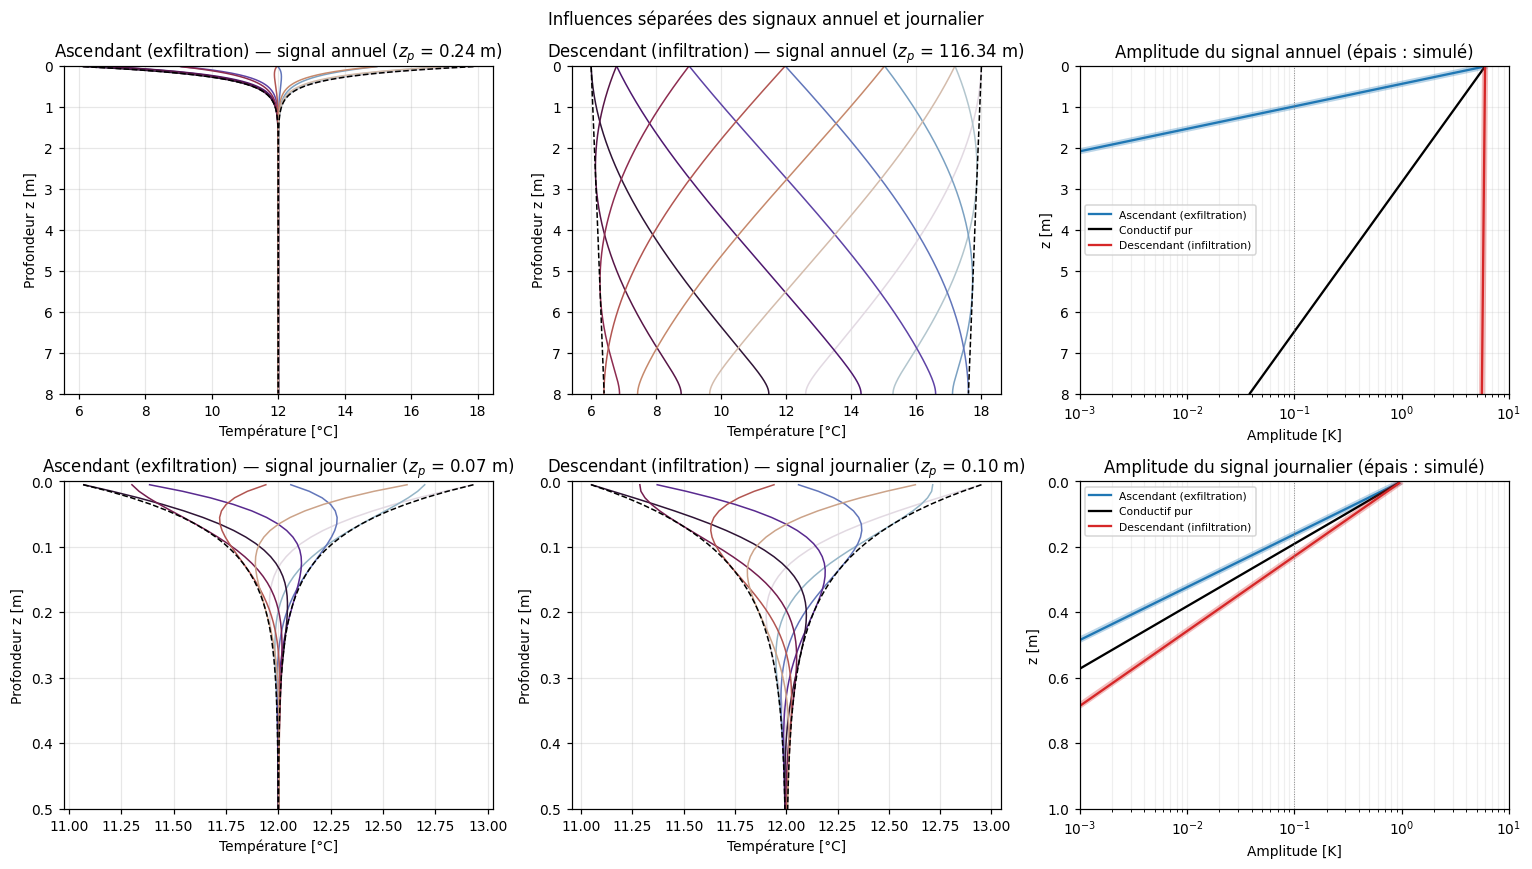

Signal annuel     Ascendant: z_p = 0.239 m  Conductif: z_p = 1.58 m  Descendant: z_p = 116 m
Signal journalier Ascendant: z_p = 0.0702 m  Conductif: z_p = 0.0829 m  Descendant: z_p = 0.0994 m


In [ ]:
PA, PJ, AA, AJ = YEAR, DAY, 6.0, 1.0                  # périodes annuelle et journalière, amplitudes 6 °C et 1 °C
cases2 = {k: v for k, v in cases.items() if k != "Conductif pur"}   # seulement infiltration et exfiltration

def run_periodic(Pv, amp, dt, nper, q, bc, save_every=1):
    """Simule nper périodes d'un signal sinusoïdal et renvoie la dernière."""
    tt = np.arange(0, nper * Pv + dt / 2, dt)         # temps de simulation
    top = TMU + amp * np.cos(2 * np.pi * tt / Pv)     # signal de surface
    ts, T = solve_transient(col, tt, top, TMU, q=q, bc_bot=bc, save_every=save_every)
    last = ts >= (nper - 1) * Pv - 1                  # dernière période (régime périodique établi)
    return ts[last] - (nper - 1) * Pv, T[last]        # temps ramenés à [0, Pv] et températures

sep = {}                                              # résultats des signaux séparés
for name, cs in cases2.items():
    sep[name] = {
        "annuel": run_periodic(PA, AA, 3 * HOUR, 3, cs["q"], cs["bc"], save_every=8),        # Δt = 3 h, 3 ans, 1 profil/jour
        "journalier": run_periodic(PJ, AJ, 0.25 * HOUR, 10, cs["q"], cs["bc"], save_every=4)  # Δt = 15 min, 10 j, 1 profil/h
    }

fig, axes = plt.subplots(2, 3, figsize=(14, 8))       # lignes : annuel / journalier ; colonnes : exfiltration, infiltration, amplitudes
for j, (name, cs) in enumerate(cases2.items()):
    for i, (lab, Pv, amp, nprof, zmax) in enumerate([("annuel", PA, AA, 12, 8), ("journalier", PJ, AJ, 8, 0.5)]):
        ts, T = sep[name][lab]                        # dernière période simulée
        idx = np.linspace(0, len(ts) - 1, nprof, endpoint=False).astype(int)   # nprof instants régulièrement espacés
        ax = axes[i, j]
        plot_profiles(ax, col.z, T[idx], cmap="twilight", lw=1)   # profils
        a, _ = stallman_ab(Pv, kap, cs["vt"])         # amortissement théorique
        ax.plot(TMU + amp * np.exp(-a * col.z), col.z, "k--", lw=1)   # enveloppe haute
        ax.plot(TMU - amp * np.exp(-a * col.z), col.z, "k--", lw=1)   # enveloppe basse
        ax.set_ylim(zmax, 0)                          # 8 m pour l'annuel, 0.5 m pour le journalier
        ax.set_title(f"{name} — signal {lab} ($z_p$ = {1/a:.2f} m)")
# 3e colonne : amplitude en fonction de la profondeur (échelle log) pour les 3 cas
for i, (lab, Pv, amp) in enumerate([("annuel", PA, AA), ("journalier", PJ, AJ)]):
    ax = axes[i, 2]
    for name, cs in cases.items():
        a, _ = stallman_ab(Pv, kap, cs["vt"])
        ax.semilogx(np.maximum(amp * np.exp(-a * col.z), 1e-4), col.z, color=cs["c"], label=name)   # théorie (tronquée à 1e-4)
        if name in sep:                               # cas simulés : amplitude mesurée par ajustement sinusoïdal
            amp_num, _ = fit_sinus(*sep[name][lab], Pv)
            ax.semilogx(amp_num, col.z, color=cs["c"], lw=4, alpha=.3)
    ax.axvline(0.1, color="grey", lw=.6, ls=":")      # repère : 0.1 K (sensibilité typique d'un capteur)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(8 if lab == "annuel" else 1, 0)
    ax.grid(which="both", alpha=.2)
    ax.set_xlabel("Amplitude [K]")
    ax.set_ylabel("z [m]")
    ax.set_title(f"Amplitude du signal {lab} (épais : simulé)")
    ax.legend(fontsize=7)
fig.suptitle("Influences séparées des signaux annuel et journalier")
plt.tight_layout()
plt.show()

for lab, Pv in [("annuel", PA), ("journalier", PJ)]:  # profondeurs de pénétration de chaque signal
    txt = "  ".join(f"{n.split()[0]}: z_p = {1/stallman_ab(Pv, kap, c['vt'])[0]:.3g} m" for n, c in cases.items())
    print(f"Signal {lab:10s} {txt}")

**Étape 2 — signal combiné.** Mise en régime sur 1 an (Δt = 30 min), puis simulation de la 2ᵉ année (stockage toutes les 3 h), et d'un zoom de 5 jours au cœur de l'été (stockage toutes les 30 min).

In [ ]:
DT2 = 0.5 * HOUR                                      # pas de temps de 30 min (48 pas par jour)

def top_comb(tt):
    """Signal combiné en surface : annuel + journalier."""
    return TMU + AA * np.cos(2 * np.pi * tt / PA) + AJ * np.cos(2 * np.pi * tt / PJ)

comb = {}                                             # résultats du signal combiné
for name, cs in cases2.items():
    # 1) mise en régime pendant 1 an (on ne garde que l'état final)
    t1 = np.arange(0, PA + DT2 / 2, DT2)
    _, T1 = solve_transient(col, t1, top_comb(t1), TMU, q=cs["q"], bc_bot=cs["bc"], save_every=10**9)
    th_start = T1[-1]                                 # état au début de l'année 2 (t = PA : maximum annuel = été)
    # 2) année 2 complète, un profil toutes les 3 h (save_every = 6 x 30 min)
    t2 = PA + np.arange(0, PA + DT2 / 2, DT2)         # temps absolus pour que le signal soit continu
    ty, Ty = solve_transient(col, t2, top_comb(t2), TMU, q=cs["q"], bc_bot=cs["bc"], theta0=th_start, save_every=6)
    # 3) zoom : 5 jours d'été au début de l'année 2, tous les pas de temps sauvés
    t3 = PA + np.arange(0, 5 * DAY + DT2 / 2, DT2)
    tz, Tz = solve_transient(col, t3, top_comb(t3), TMU, q=cs["q"], bc_bot=cs["bc"], theta0=th_start, save_every=1)
    # vérification de la superposition : somme des deux solutions de Stallman
    ana = (stallman(col.z[None, :], ty[:, None], PA, AA, TMU, kap, cs["vt"])   # réponse au signal annuel (moyenne 12 °C)
           + stallman(col.z[None, :], ty[:, None], PJ, AJ, 0.0, kap, cs["vt"]))  # + réponse au signal journalier (moyenne 0)
    comb[name] = dict(ty=ty - PA, Ty=Ty, tz=tz - PA, Tz=Tz)   # temps ramenés à partir de 0
    err = np.abs(Ty - ana).max(axis=0)                # écart maximal à chaque profondeur
    print(f"{name:27s} écart max simulation / superposition des solutions de Stallman : "
          f"{err[col.z < 7.5].max():.1e} K sur 0–7.5 m, {err.max():.1e} K au maximum (bord inclus)")

Ascendant (exfiltration)    écart max simulation / superposition des solutions de Stallman : 5.2e-03 K sur 0–7.5 m, 5.2e-03 K au maximum (bord inclus)


Descendant (infiltration)   écart max simulation / superposition des solutions de Stallman : 3.1e-02 K sur 0–7.5 m, 2.5e-01 K au maximum (bord inclus)


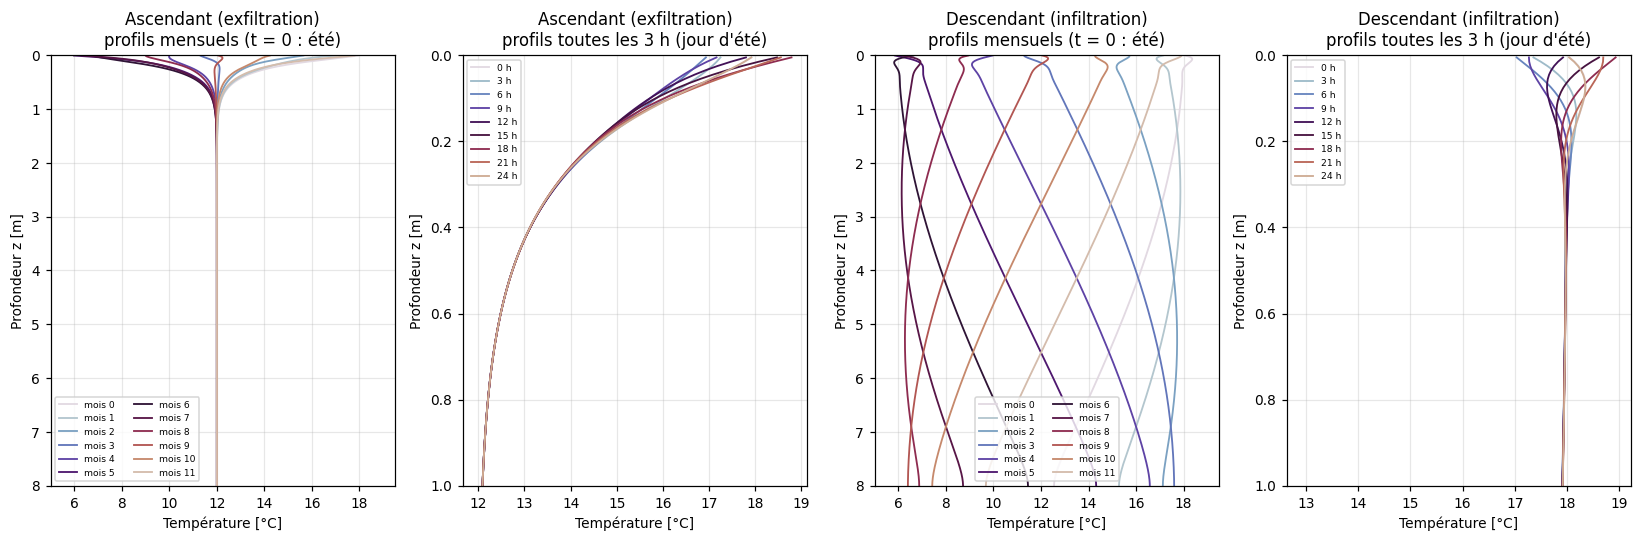

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))       # 2 graphiques par cas
for j, (name, cs) in enumerate(cases2.items()):
    c = comb[name]
    # profils mensuels sur l'année
    ax = axes[2 * j]
    months = np.searchsorted(c["ty"], np.arange(12) * PA / 12)   # indices des instants t = 0, PA/12, 2PA/12...
    plot_profiles(ax, col.z, c["Ty"][months], cmap="twilight", lw=1.2, labels=[f"mois {m}" for m in range(12)])
    ax.set_ylim(8, 0)
    ax.set_xlim(5, 19.5)
    ax.set_title(f"{name}\nprofils mensuels (t = 0 : été)")
    ax.legend(fontsize=6, ncol=2)
    # profils toutes les 3 h pendant une journée d'été (5e jour du zoom)
    ax = axes[2 * j + 1]
    day = (c["tz"] >= 4 * DAY) & ((c["tz"] - 4 * DAY) % (3 * HOUR) < 1)   # instants du 5e jour multiples de 3 h
    labels = [f"{(tt - 4 * DAY) / HOUR:.0f} h" for tt in c["tz"][day]]   # heure dans la journée
    plot_profiles(ax, col.z, c["Tz"][day], cmap="twilight", lw=1.2, labels=labels)
    ax.set_ylim(1.0, 0)                               # zoom sur le premier mètre
    ax.set_title(f"{name}\nprofils toutes les 3 h (jour d'été)")
    ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

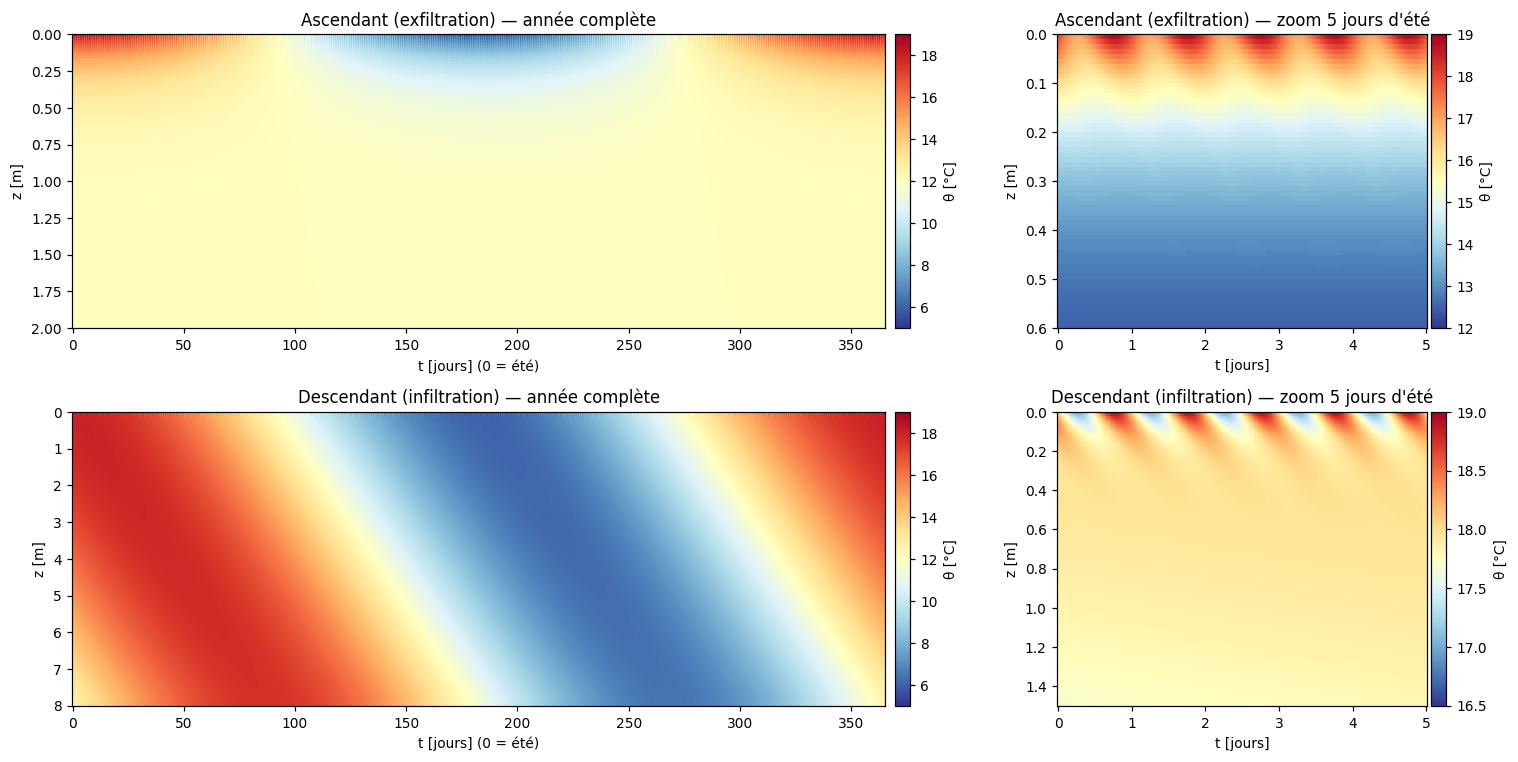

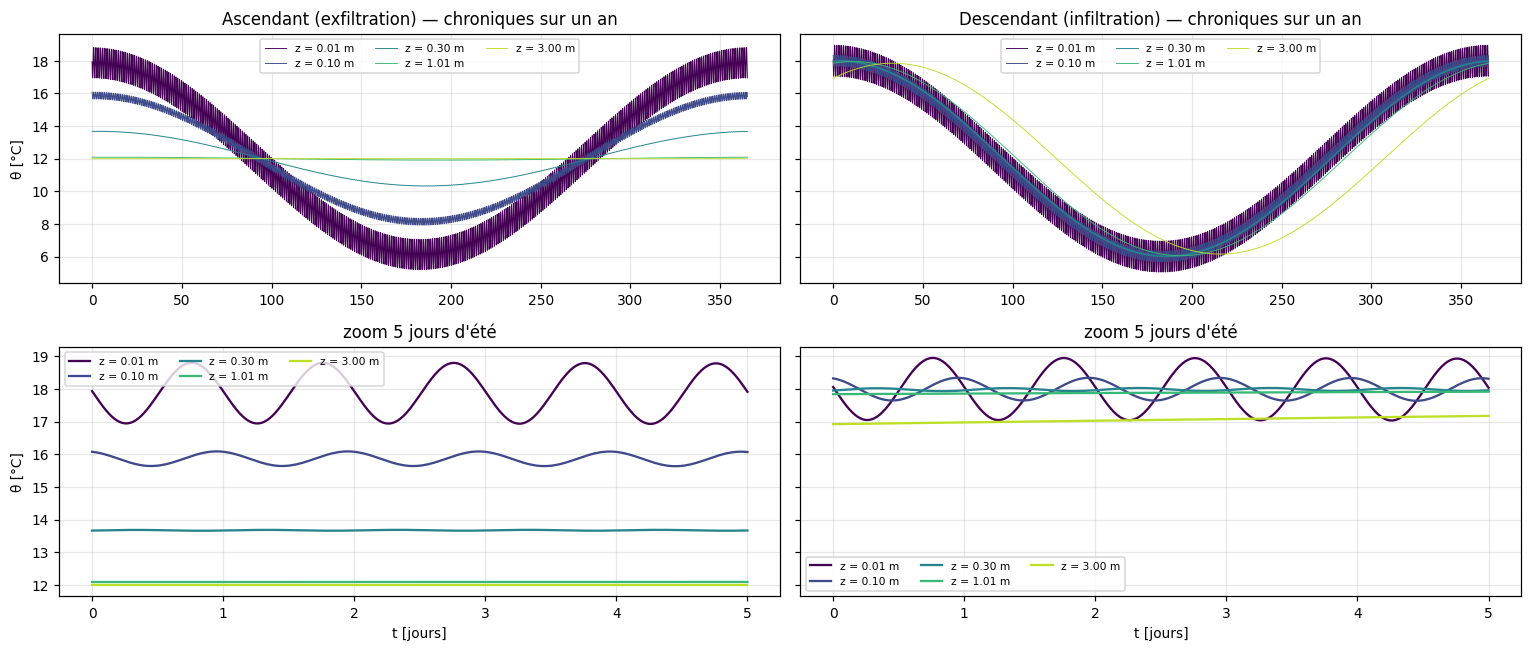

In [ ]:
# --- frises : année complète (à gauche) et zoom de 5 jours (à droite)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), gridspec_kw={"width_ratios": [2.2, 1]})
for i, (name, cs) in enumerate(cases2.items()):
    c = comb[name]
    up = cs["q"] < 0                                  # True en exfiltration : on zoome davantage (signal confiné)
    plot_frise(axes[i, 0], c["ty"], col.z, c["Ty"], vmin=5, vmax=19, label="θ [°C]", cmap="RdYlBu_r",
               zmax=2 if up else 8)
    axes[i, 0].set_title(f"{name} — année complète")
    axes[i, 0].set_xlabel("t [jours] (0 = été)")
    plot_frise(axes[i, 1], c["tz"], col.z, c["Tz"], vmin=12 if up else 16.5, vmax=19, label="θ [°C]",
               cmap="RdYlBu_r", zmax=0.6 if up else 1.5)
    axes[i, 1].set_title(f"{name} — zoom 5 jours d'été")
    axes[i, 1].set_xlabel("t [jours]")
plt.tight_layout()
plt.show()

# --- chroniques de température à quelques profondeurs
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharey="row")   # ligne 1 : un an ; ligne 2 : 5 jours
depths = [0.0, 0.1, 0.3, 1.0, 3.0]                    # profondeurs de "capteurs" virtuels [m]
colors_d = plt.cm.viridis(np.linspace(0, .9, len(depths)))
for j, (name, cs) in enumerate(cases2.items()):
    c = comb[name]
    for d, colr in zip(depths, colors_d):
        k = np.searchsorted(col.z, d)                 # indice de la maille la plus proche de d
        axes[0, j].plot(c["ty"] / DAY, c["Ty"][:, k], color=colr, lw=.6, label=f"z = {col.z[k]:.2f} m")
        axes[1, j].plot(c["tz"] / DAY, c["Tz"][:, k], color=colr, label=f"z = {col.z[k]:.2f} m")
    axes[0, j].set_title(f"{name} — chroniques sur un an")
    axes[1, j].set_title("zoom 5 jours d'été")
    for ax in axes[:, j]:
        ax.grid(alpha=.3)
        ax.legend(fontsize=7, ncol=3)
    axes[1, j].set_xlabel("t [jours]")
axes[0, 0].set_ylabel("θ [°C]")
axes[1, 0].set_ylabel("θ [°C]")
plt.tight_layout()
plt.show()

**Commentaires 2.4.2**

- **Superposition** : la simulation du signal combiné coïncide avec la somme des deux solutions de Stallman (écart ≤ 3·10⁻² K sur 0–7.5 m, pour une amplitude totale de 7 K) : l'équation étant linéaire à écoulement fixé, les deux signaux se propagent **indépendamment**, chacun avec son propre $a$ et son propre $b$. Le seul écart notable (≈ 0.25 K) apparaît en infiltration dans les derniers décimètres : le signal annuel n'y est pas amorti et la condition de sortie libre (flux conductif nul) diffère de la colonne semi‑infinie de Stallman sur une épaisseur ≈ $\kappa_e/v_t$ = 0.24 m. Une colonne plus longue ferait disparaître cet effet de bord.
- **Filtrage par la profondeur** : le sol agit comme un **filtre passe‑bas** dont la fréquence de coupure diminue avec la profondeur. Le signal journalier ne subsiste que dans les premiers centimètres ($z_p$ ≈ 7 cm en exfiltration, 8 cm en conduction, 10 cm en infiltration à 10⁻⁶ m/s : l'écoulement modifie peu le signal journalier car $P_j \ll P_c$ ≈ 67 j) ; en dessous, on ne voit plus que le cycle annuel. Sur les chroniques, les oscillations journalières disparaissent entre 0.1 et 0.3 m.
- **Infiltration** : le signal annuel est à peine amorti ($z_p$ ≈ 120 m) : sur toute la colonne, la température suit la rivière avec un retard qui croît avec la profondeur (≈ 3 mois à 8 m, lisible à la pente des bandes de la frise). Le signal journalier, lui, n'est presque pas affecté par l'écoulement.
- **Exfiltration** : le signal annuel, pourtant d'amplitude 6 °C, est confiné dans une couche limite de ≈ 25 cm ($\kappa_e/|v_t|$) : en dessous de 1 m, la température reste à 12 °C toute l'année. Le signal journalier est un peu plus amorti qu'en conduction mais reste d'épaisseur comparable.
- **Conséquences pour la mesure** : les deux fréquences sont complémentaires. Le signal journalier donne une information locale, en très proche surface, peu sensible à $q$ pour ces débits ; le signal annuel est très sensible au sens et à l'intensité de l'écoulement mais demande une chronique longue. Un capteur placé à quelques dizaines de centimètres distingue immédiatement les deux régimes : forte variation saisonnière en infiltration, température quasi constante en exfiltration.